In [120]:
import pandas as pd
from tqdm import tqdm
import json
import requests 
from bs4 import BeautifulSoup
import ollama
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np
import matplotlib.pyplot as plt
import time
from googlenewsdecoder import new_decoderv1
import seaborn as sns

In [ ]:
nfl_df = pd.read_csv("nfl_media.csv")
nfl_df.head()

,ID,Player Name,Player Status,Year of Event,Statement Made,Event Description,Platform,Event Type,Media Tone,Post Status,Media Coverage,Sources,URL,Unnamed: 13,Unnamed: 14
0,1.0,Jason Kelce,Retired,2025.0,Man I love the 4th...we all share in common th...,Instagram post celebrating July 4th sparked ba...,Instagram,Controversy,Negative,Active,High,"Fox News, US Weekly, Yahoo Sports",https://www.yahoo.com/entertainment/articles/j...,NaN,NaN
1,2.0,Warren Sapp,Retired,2025.0,Texas is Fake Football,Response to a tweet that praises Texas running...,Twitter/X,Controversy,Negative,Deleted,Medium,"MSN, Yahoo Sports",https://sports.yahoo.com/articles/nfl-legend-w...,NaN,NaN
2,3.0,Puka Nacua,Playing,2025.0,I deeply apologize...I do not stand for any fo...,Apologizes after making antisemitic gesture du...,Instagram,Apology,Negative,Deleted,High,"CNN, Yahoo Sports, BBC",https://www.cnn.com/2025/12/18/sport/football-...,NaN,NaN
3,4.0,Travis Kelce,Playing,2024.0,happy easter...#shoutout to Jesus for takin on...,Wishing everyone a Happy Easter while making j...,Twitter/X,Controversy,Mixed,Active,High,"Yahoo Sports, E! News, People",https://www.yahoo.com/entertainment/articles/t...,NaN,NaN
4,5.0,Deion Sanders,Playing,2024.0,He will be a top 5 pick. Where yo son going?,Response to a fan about the draft pick ranking...,Twitter/X,Controversy,Negative,Deleted,Medium,"Yahoo Sports, ESPN, Fox News",https://sports.yahoo.com/article/deion-sanders...,NaN,NaN


### Webscraping

In [3]:
# New
import trafilatura

def get_website_text(url):
    downloaded = trafilatura.fetch_url(url)
    if downloaded:
        return trafilatura.extract(downloaded)
    return None

In [4]:
test_nfl_df = nfl_df[0:75].copy()
test_nfl_df['website_text'] = test_nfl_df['URL'].apply(get_website_text)

In [5]:
test_nfl_df['website_text'].notna().value_counts()

website_text
True     72
False     3
Name: count, dtype: int64

There are 72 out of the 75 events that have code 200 (i.e. worked)

In [6]:
test_nfl_df.head()

,ID,Player Name,Player Status,Year of Event,Statement Made,Event Description,Platform,Event Type,Media Tone,Post Status,Media Coverage,Sources,URL,Unnamed: 13,Unnamed: 14,website_text
0,1.0,Jason Kelce,Retired,2025.0,Man I love the 4th...we all share in common th...,Instagram post celebrating July 4th sparked ba...,Instagram,Controversy,Negative,Active,High,"Fox News, US Weekly, Yahoo Sports",https://www.yahoo.com/entertainment/articles/j...,NaN,NaN,Jason Kelce slammed for ‘tone deaf’ Fourth of ...
1,2.0,Warren Sapp,Retired,2025.0,Texas is Fake Football,Response to a tweet that praises Texas running...,Twitter/X,Controversy,Negative,Deleted,Medium,"MSN, Yahoo Sports",https://sports.yahoo.com/articles/nfl-legend-w...,NaN,NaN,NFL legend Warren Sapp calls Texas ‘fake footb...
2,3.0,Puka Nacua,Playing,2025.0,I deeply apologize...I do not stand for any fo...,Apologizes after making antisemitic gesture du...,Instagram,Apology,Negative,Deleted,High,"CNN, Yahoo Sports, BBC",https://www.cnn.com/2025/12/18/sport/football-...,NaN,NaN,Los Angeles Rams receiver Puka Nacua has apolo...
3,4.0,Travis Kelce,Playing,2024.0,happy easter...#shoutout to Jesus for takin on...,Wishing everyone a Happy Easter while making j...,Twitter/X,Controversy,Mixed,Active,High,"Yahoo Sports, E! News, People",https://www.yahoo.com/entertainment/articles/t...,NaN,NaN,Travis Kelce’s Resurfaced Easter Tweet Goes Vi...
4,5.0,Deion Sanders,Playing,2024.0,He will be a top 5 pick. Where yo son going?,Response to a fan about the draft pick ranking...,Twitter/X,Controversy,Negative,Deleted,Medium,"Yahoo Sports, ESPN, Fox News",https://sports.yahoo.com/article/deion-sanders...,NaN,NaN,Deion Sanders Eats Crow After His Shedeur Sand...


In [7]:
test_nfl_df_true = test_nfl_df.dropna(subset='website_text')

In [8]:
test_nfl_df_true.columns

Index(['ID', 'Player Name', 'Player Status', 'Year of Event', 'Statement Made',
       'Event Description', 'Platform', 'Event Type', 'Media Tone',
       'Post Status', 'Media Coverage', 'Sources', 'URL', 'Unnamed: 13',
       'Unnamed: 14', 'website_text'],
      dtype='str')

In [9]:
test_nfl_df_true = test_nfl_df_true.drop(columns=['Unnamed: 13', 'Unnamed: 14'])

In [10]:
test_nfl_df_true.head()

,ID,Player Name,Player Status,Year of Event,Statement Made,Event Description,Platform,Event Type,Media Tone,Post Status,Media Coverage,Sources,URL,website_text
0,1.0,Jason Kelce,Retired,2025.0,Man I love the 4th...we all share in common th...,Instagram post celebrating July 4th sparked ba...,Instagram,Controversy,Negative,Active,High,"Fox News, US Weekly, Yahoo Sports",https://www.yahoo.com/entertainment/articles/j...,Jason Kelce slammed for ‘tone deaf’ Fourth of ...
1,2.0,Warren Sapp,Retired,2025.0,Texas is Fake Football,Response to a tweet that praises Texas running...,Twitter/X,Controversy,Negative,Deleted,Medium,"MSN, Yahoo Sports",https://sports.yahoo.com/articles/nfl-legend-w...,NFL legend Warren Sapp calls Texas ‘fake footb...
2,3.0,Puka Nacua,Playing,2025.0,I deeply apologize...I do not stand for any fo...,Apologizes after making antisemitic gesture du...,Instagram,Apology,Negative,Deleted,High,"CNN, Yahoo Sports, BBC",https://www.cnn.com/2025/12/18/sport/football-...,Los Angeles Rams receiver Puka Nacua has apolo...
3,4.0,Travis Kelce,Playing,2024.0,happy easter...#shoutout to Jesus for takin on...,Wishing everyone a Happy Easter while making j...,Twitter/X,Controversy,Mixed,Active,High,"Yahoo Sports, E! News, People",https://www.yahoo.com/entertainment/articles/t...,Travis Kelce’s Resurfaced Easter Tweet Goes Vi...
4,5.0,Deion Sanders,Playing,2024.0,He will be a top 5 pick. Where yo son going?,Response to a fan about the draft pick ranking...,Twitter/X,Controversy,Negative,Deleted,Medium,"Yahoo Sports, ESPN, Fox News",https://sports.yahoo.com/article/deion-sanders...,Deion Sanders Eats Crow After His Shedeur Sand...


In [11]:
test_nfl_df_true.website_text.str.len()

0     3162
1     3058
2     1677
3     1801
4     2020
      ... 
70    7488
71    3324
72    5328
73    4039
74    3370
Name: website_text, Length: 72, dtype: int64

#### GoogleNews

2019-2020

In [1]:
from GoogleNews import GoogleNews
googlenews = GoogleNews(lang='en', region='US', start='01/01/2019', end='01/01/2020',encode='utf-8')

In [136]:
googlenews.get_news('NFL controversy')

'NoneType' object has no attribute 'get'


In [137]:
googlenews.total_count()

0

In [ ]:
results_2019= googlenews.results()

In [ ]:
results_2019

[{'title': 'NFL to hold workout for Colin Kaepernick 3 years after kneeling controversy',
  'desc': None,
  'date': 'Nov 15, 2019',
  'datetime': nan,
  'link': 'https://news.google.com/read/CBMirAFBVV95cUxOdHhya0xncUt6R19kU3diVzdTWmhCc2VmVEc4S0UwbnN6bVRMd0pFZ3BSMzczbHFsR2RVRFFuSFEwY0ZWQXpqczVuTG00RkNrdzZySGFYUklmelJyMHd1b1dEYlh4TVRHZXNRM3pMRkZCdjM4ZXZ4enNQZEpkc2JoOXdxY3hUU19YdFVabk9PLTNiWXkwQjBrVUJJVnBoRjB3bmtTRzRxaEFlNng50gGyAUFVX3lxTFBoU2lEWUNmYUdpbDRiRFBLR3R4VUs4akNhWnA4OTFqZHl4VHVteWdMSm5DbE1LTW52eC0wd2E4NmxGVUcyTHhQMHY4UnlLRU9zUUVncDZISGhFVnlEc2UxRHRkaWR6eUxQTHhQRzBaRW1BU0pvUkwtMTVuWG1Ec280WnJnOXdKWFhJME1kc21tZnd6SWdzMG1GaDVKbFpWX3dJeWFvNnZ1WXJHLXFYQkFzRVE?hl=en-US&gl=US&ceid=US%3Aen',
  'img': 'https://news.google.com/api/attachments/CC8iK0NnNTFVbVV6YW1WNk9VOUxhbUo2VFJDZkF4ampCU2dLTWdhdEJJNnZqUW8=-w200-h112-p-df',
  'media': 'CNBC',
  'site': None,
  'reporter': None},
 {'title': 'NFL to hold workout for Colin Kaepernick 3 years after kneeling controversy',
  'desc': None,
  'da

In [ ]:
print(type(results_2019))

<class 'list'>


In [ ]:
len(results_2019)

201

In [ ]:
seen = set()
unique_results = []
for item in results_2019:
    if item["title"] not in seen:
        seen.add(item["title"])
        unique_results.append(item)

In [143]:
unique_results

[{'title': 'NFL to hold workout for Colin Kaepernick 3 years after kneeling controversy',
  'desc': None,
  'date': 'Nov 15, 2019',
  'datetime': nan,
  'link': 'https://news.google.com/read/CBMirAFBVV95cUxOdHhya0xncUt6R19kU3diVzdTWmhCc2VmVEc4S0UwbnN6bVRMd0pFZ3BSMzczbHFsR2RVRFFuSFEwY0ZWQXpqczVuTG00RkNrdzZySGFYUklmelJyMHd1b1dEYlh4TVRHZXNRM3pMRkZCdjM4ZXZ4enNQZEpkc2JoOXdxY3hUU19YdFVabk9PLTNiWXkwQjBrVUJJVnBoRjB3bmtTRzRxaEFlNng50gGyAUFVX3lxTFBoU2lEWUNmYUdpbDRiRFBLR3R4VUs4akNhWnA4OTFqZHl4VHVteWdMSm5DbE1LTW52eC0wd2E4NmxGVUcyTHhQMHY4UnlLRU9zUUVncDZISGhFVnlEc2UxRHRkaWR6eUxQTHhQRzBaRW1BU0pvUkwtMTVuWG1Ec280WnJnOXdKWFhJME1kc21tZnd6SWdzMG1GaDVKbFpWX3dJeWFvNnZ1WXJHLXFYQkFzRVE?hl=en-US&gl=US&ceid=US%3Aen',
  'img': 'https://news.google.com/api/attachments/CC8iK0NnNTFVbVV6YW1WNk9VOUxhbUo2VFJDZkF4ampCU2dLTWdhdEJJNnZqUW8=-w200-h112-p-df',
  'media': 'CNBC',
  'site': None,
  'reporter': None},
 {'title': "NFL rumors: Patriots’ Tom Brady gets involved in helmet controversy | 'I’m dealing with it’",
  'de

In [144]:
len(unique_results)

100

After saving the results into a dataframe, I noticed that the links were no longer working, so we would have to resolve that problem before proceeding. 

In [145]:
unique_results = [i for i in unique_results if i["link"]]

In [146]:
len(unique_results)

99

In [147]:
for i in unique_results:
    i['website_text'] = get_website_text(i['link'])

In [148]:
from googlenewsdecoder import new_decoderv1
import trafilatura
import time

def resolve_url(url):
    try:
        result = new_decoderv1(url)
        if result.get("status"):
            return result["decoded_url"]
        return None
    except Exception:
        return None

def get_website_text(url):
    downloaded = trafilatura.fetch_url(url)
    if downloaded:
        return trafilatura.extract(downloaded)
    return None

for i in unique_results:
    resolved = resolve_url(i["link"])       # Step 1: resolve the Google URL
    i["resolved_url"] = resolved            # Step 2: store it
    i["website_text"] = get_website_text(resolved) if resolved else None  # Step 3: scrape
    time.sleep(0.5)                         # Step 4: avoid rate limiting

In [149]:
len(unique_results)

99

In [163]:
nfl_news_2019 = pd.DataFrame(unique_results)

In [164]:
nfl_news_2019['resolved_url']

0     https://www.cnbc.com/2019/11/13/colin-kaeperni...
1     https://www.nj.com/giants/2019/08/nfl-rumors-p...
2     https://www.wcvb.com/article/controversy-grows...
3     https://www.nytimes.com/2019/02/15/sports/nfl-...
4     https://www.nfl.com/news/sidelines/controversi...
                            ...                        
94         https://time.com/5696356/rihanna-super-bowl/
95    https://www.vox.com/the-goods/2019/1/15/181836...
96    https://www.news.com.au/sport/american-sports/...
97    https://www.goldderby.com/reality-tv/2019/ray-...
98    https://www.washingtonpost.com/sports/2019/09/...
Name: resolved_url, Length: 99, dtype: str

In [165]:
nfl_news_2019['website_text'].str.len()

0      1668.0
1         NaN
2      4105.0
3         NaN
4     14865.0
       ...   
94        NaN
95     5706.0
96        NaN
97     2825.0
98        NaN
Name: website_text, Length: 99, dtype: float64

In [166]:
nfl_news_2019['website_text'].isna().sum()

np.int64(20)

In [167]:
nfl_news_2019[nfl_news_2019['website_text'].isna()].head()

,title,desc,date,datetime,link,img,media,site,reporter,website_text,resolved_url
1,NFL rumors: Patriots’ Tom Brady gets involved ...,None,"Aug 12, 2019",NaN,https://news.google.com/read/CBMiswFBVV95cUxOT...,https://news.google.com/api/attachments/CC8iK0...,NJ.com,None,By Todderick Hunt,NaN,https://www.nj.com/giants/2019/08/nfl-rumors-p...
3,A Timeline of Colin Kaepernick vs. the N.F.L. ...,None,"Feb 15, 2019",NaN,https://news.google.com/read/CBMijgFBVV95cUxON...,https://news.google.com/api/attachments/CC8iK0...,The New York Times,None,By Victor Mather,NaN,https://www.nytimes.com/2019/02/15/sports/nfl-...
6,Your Guide to the 2019 Super Bowl Halftime Sho...,None,"Jan 18, 2019",NaN,https://news.google.com/read/CBMidkFVX3lxTFBIR...,https://news.google.com/api/attachments/CC8iK0...,Time Magazine,None,By Cady Lang,NaN,https://time.com/5505825/super-bowl-halftime-s...
11,"Jets cut Kelechi Osemele amid injury dispute, ...",None,"Oct 26, 2019",NaN,https://news.google.com/read/CBMingFBVV95cUxQU...,https://news.google.com/api/attachments/CC8iL0...,ESPN,None,By Rich Cimini,NaN,https://www.espn.com/nfl/story/_/id/27934491/j...
14,"Analysis | Since the NFL anthem protests, whit...",None,"Jan 19, 2019",NaN,https://news.google.com/read/CBMigAJBVV95cUxQQ...,https://news.google.com/api/attachments/CC8iI0...,The Washington Post,None,NaN,NaN,https://www.washingtonpost.com/news/monkey-cag...


In [168]:
nfl_news_2020 = nfl_news_2019.dropna(subset=['website_text'])

In [169]:
nfl_news_2019.shape

(99, 11)

In [171]:
nfl_news_2019['title'].head()

0    NFL to hold workout for Colin Kaepernick 3 yea...
1    NFL rumors: Patriots’ Tom Brady gets involved ...
2    Controversy grows as NFL cancels Maroon 5 pre-...
3    A Timeline of Colin Kaepernick vs. the N.F.L. ...
4    Immaculate Reception debate rages on five deca...
Name: title, dtype: str

In [172]:
# This looks for any sequence of 4 digits (\d{4})
# The ~ at the beginning negates the logic (i.e., "Find where this is NOT true")
missing_year_mask = ~nfl_news_2019['date'].astype(str).str.contains(r'\d{4}', regex=True)

# View the entries missing a year
entries_missing_year = nfl_news_2019[missing_year_mask]
print(entries_missing_year[['date']])

Empty DataFrame
Columns: [date]
Index: []


In [218]:
nfl_news_2019.to_csv("nfl_news_2019.csv", index=False)

2020 - 2021

In [173]:
googlenews = GoogleNews(lang='en', region='US', start='01/02/2020', end='01/01/2021',encode='utf-8')

In [174]:
googlenews.get_news('NFL controversy')

'NoneType' object has no attribute 'get'


In [175]:
googlenews.total_count()

0

In [176]:
results_2020 = googlenews.results()

In [177]:
seen = set()
unique_results = []
for item in results_2020:
    if item["title"] not in seen:
        seen.add(item["title"])
        unique_results.append(item)


In [178]:
unique_results_2020 = [i for i in unique_results if i["link"]]

In [179]:
for i in unique_results_2020:
    i['website_text'] = get_website_text(i['link'])

In [180]:
def resolve_url(url):
    try:
        result = new_decoderv1(url)
        if result.get("status"):
            return result["decoded_url"]
        return None
    except Exception:
        return None

def get_website_text(url):
    downloaded = trafilatura.fetch_url(url)
    if downloaded:
        return trafilatura.extract(downloaded)
    return None

for i in unique_results_2020:
    resolved = resolve_url(i["link"])       # Step 1: resolve the Google URL
    i["resolved_url"] = resolved            # Step 2: store it
    i["website_text"] = get_website_text(resolved) if resolved else None  # Step 3: scrape
    time.sleep(0.5)                         # Step 4: avoid rate limiting

In [181]:
len(unique_results_2020)

76

In [182]:
nfl_news_2020 = pd.DataFrame(unique_results_2020)
nfl_news_2020.head()

,title,desc,date,datetime,link,img,media,site,reporter,website_text,resolved_url
0,Top 10 NFL controversial plays,None,"May 15, 2020",NaN,https://news.google.com/read/CBMif0FVX3lxTFBrd...,https://news.google.com/api/attachments/CC8iL0...,NFL.com,None,NaN,NFL Photos | NFL Photography Gallery | NFL.com...,https://www.nfl.com/photos/top-10-nfl-controve...
1,How the NFL Responded to the Colin Kaepernick ...,None,"Nov 24, 2020",NaN,https://news.google.com/read/CBMi1gJBVV95cUxQc...,NaN,The Sport Journal,None,By Ben Donahue,"Authors: Ben Donahue, MS, MEd\nCorresponding A...",https://thesportjournal.org/article/how-the-nf...
2,Madden NFL 21 User Score Controversy Explained,None,"Aug 31, 2020",NaN,https://news.google.com/read/CBMihgFBVV95cUxNc...,https://news.google.com/api/attachments/CC8iK0...,Den of Geek,None,By Matthew Byrd,Madden NFL 21 User Score Controversy Explained...,https://www.denofgeek.com/games/madden-nfl-21-...
3,Opinion: The Patriots’ early exit from the NFL...,None,"Jan 25, 2020",NaN,https://news.google.com/read/CBMixwFBVV95cUxOb...,https://news.google.com/api/attachments/CC8iI0...,HS Insider,None,NaN,Boring. Predictable. Monotonous.\nThese are al...,https://highschool.latimes.com/sports/opinion-...
4,NFL At 100: A look at the biggest scandals in ...,None,"Mar 4, 2020",NaN,https://news.google.com/read/CBMimgFBVV95cUxPX...,https://news.google.com/api/attachments/CC8iK0...,FOX Sports,None,NaN,NFL At 100: A look at the biggest scandals in ...,https://www.foxsports.com/stories/nfl/nfl-at-1...


In [183]:
nfl_news_2020['website_text'].isna().sum()

np.int64(16)

In [184]:
nfl_news_2020 = nfl_news_2020.dropna(subset=['website_text'])

In [185]:
nfl_news_2020['title'].head()

0                       Top 10 NFL controversial plays
1    How the NFL Responded to the Colin Kaepernick ...
2       Madden NFL 21 User Score Controversy Explained
3    Opinion: The Patriots’ early exit from the NFL...
4    NFL At 100: A look at the biggest scandals in ...
Name: title, dtype: str

In [186]:
nfl_news_2020.shape

(60, 11)

In [187]:
# This looks for any sequence of 4 digits (\d{4})
# The ~ at the beginning negates the logic (i.e., "Find where this is NOT true")
missing_year_mask = ~nfl_news_2020['date'].astype(str).str.contains(r'\d{4}', regex=True)

# View the entries missing a year
entries_missing_year = nfl_news_2020[missing_year_mask]
print(entries_missing_year[['date']])

Empty DataFrame
Columns: [date]
Index: []


In [219]:
nfl_news_2020.to_csv("nfl_news_2020.csv", index=False)

2021 - 2022

In [140]:
googlenews = GoogleNews(lang='en', region='US', start='01/02/2021', end='01/01/2022',encode='utf-8')

In [141]:
googlenews.get_news('NFL controversy')

'NoneType' object has no attribute 'get'


In [142]:
googlenews.total_count()

0

In [143]:
results_2021 = googlenews.results()

In [144]:
seen = set()
unique_results = []
for item in results_2021:
    if item["title"] not in seen:
        seen.add(item["title"])
        unique_results.append(item)

In [145]:
unique_results_2021 = [i for i in unique_results if i["link"]]

In [146]:
for i in unique_results_2021:
    i['website_text'] = get_website_text(i['link'])

In [147]:
def resolve_url(url):
    try:
        result = new_decoderv1(url)
        if result.get("status"):
            return result["decoded_url"]
        return None
    except Exception:
        return None

def get_website_text(url):
    downloaded = trafilatura.fetch_url(url)
    if downloaded:
        return trafilatura.extract(downloaded)
    return None

for i in unique_results_2021:
    resolved = resolve_url(i["link"])       # Step 1: resolve the Google URL
    i["resolved_url"] = resolved            # Step 2: store it
    i["website_text"] = get_website_text(resolved) if resolved else None  # Step 3: scrape
    time.sleep(0.5)  

len(unique_results_2021)

84

In [148]:
nfl_news_2021 = pd.DataFrame(unique_results_2021)
nfl_news_2021.head()

,title,desc,date,datetime,link,img,media,site,reporter,website_text,resolved_url
0,8 Scandals That Rocked the NFL,None,"Aug 26, 2021",NaN,https://news.google.com/read/CBMiaEFVX3lxTE5zQ...,https://news.google.com/api/attachments/CC8iL0...,History.com,None,By Sean Keane,"In December 1925, the Pottsville (Pa.) Maroons...",https://www.history.com/articles/nfl-scandals-...
1,We were robbed! Most memorable officiating con...,None,"Jan 20, 2021",NaN,https://news.google.com/read/CBMiuAFBVV95cUxPW...,https://news.google.com/api/attachments/CC8iL0...,ESPN,None,NaN,NaN,https://www.espn.com/nfl/story/_/id/28397300/w...
2,Tension boiling over between coach Urban Meyer...,None,"Dec 11, 2021",NaN,https://news.google.com/read/CBMimAFBVV95cUxQN...,https://news.google.com/api/attachments/CC8iK0...,NFL.com,None,By Tom Pelissero,Months of tension surrounding Jaguars coach Ur...,https://www.nfl.com/news/tension-boiling-over-...
3,"From bar video to kicking kicker, Urban Meyer ...",None,"Dec 16, 2021",NaN,https://news.google.com/read/CBMi4wFBVV95cUxQS...,https://news.google.com/api/attachments/CC8iK0...,The Florida Times-Union,None,By Garry Smits,"From bar video to kicking kicker, Urban Meyer ...",https://www.jacksonville.com/story/sports/nfl/...
4,Raiders Coach Resigns After Homophobic and Mis...,None,"Oct 28, 2021",NaN,https://news.google.com/read/CBMihgFBVV95cUxPU...,https://news.google.com/api/attachments/CC8iK0...,The New York Times,None,By Ken Belson & Katherine Rosman,NaN,https://www.nytimes.com/2021/10/11/sports/foot...


In [149]:
nfl_news_2021['website_text'].isna().sum()

np.int64(14)

In [150]:
nfl_news_2021 = nfl_news_2021.dropna(subset=['website_text'])

In [151]:
nfl_news_2021['title'].head()

0                       8 Scandals That Rocked the NFL
2    Tension boiling over between coach Urban Meyer...
3    From bar video to kicking kicker, Urban Meyer ...
5    Colin Kaepernick in Netflix series likens NFL ...
7    Urban Meyer ‘devastated’ after being fired fro...
Name: title, dtype: str

In [152]:
nfl_news_2021.shape

(70, 11)

In [153]:
# This looks for any sequence of 4 digits (\d{4})
# The ~ at the beginning negates the logic (i.e., "Find where this is NOT true")
missing_year_mask = ~nfl_news_2021['date'].astype(str).str.contains(r'\d{4}', regex=True)

# View the entries missing a year
entries_missing_year = nfl_news_2021[missing_year_mask]
print(entries_missing_year[['date']])

Empty DataFrame
Columns: [date]
Index: []


In [154]:
nfl_news_2021.to_csv("nfl_news_2021.csv", index=False)

2022 - 2023

In [221]:
googlenews = GoogleNews(lang='en', region='US', start='01/02/2022', end='01/01/2023',encode='utf-8')

In [222]:
googlenews.get_news('NFL controversy')

'NoneType' object has no attribute 'get'


In [223]:
googlenews.total_count()

0

In [224]:
results_2022 = googlenews.results()

In [225]:
seen = set()
unique_results = []
for item in results_2022:
    if item["title"] not in seen:
        seen.add(item["title"])
        unique_results.append(item)

In [226]:
len(unique_results)

101

In [227]:
unique_results_2022 = [i for i in unique_results if i["link"]]

In [228]:
len(unique_results_2022)

100

In [229]:
for i in unique_results_2022:
    i['website_text'] = get_website_text(i['link'])

In [230]:
def resolve_url(url):
    try:
        result = new_decoderv1(url)
        if result.get("status"):
            return result["decoded_url"]
        return None
    except Exception:
        return None

def get_website_text(url):
    downloaded = trafilatura.fetch_url(url)
    if downloaded:
        return trafilatura.extract(downloaded)
    return None

for i in unique_results_2022:
    resolved = resolve_url(i["link"])       # Step 1: resolve the Google URL
    i["resolved_url"] = resolved            # Step 2: store it
    i["website_text"] = get_website_text(resolved) if resolved else None  # Step 3: scrape
    time.sleep(0.5)  

len(unique_results_2022)

100

In [231]:
nfl_news_2022 = pd.DataFrame(unique_results_2022)
nfl_news_2022.head() 

,title,desc,date,datetime,link,img,media,site,reporter,website_text,resolved_url
0,Explaining the NFL's latest concussion controv...,None,"Oct 13, 2022",NaN,https://news.google.com/read/CBMicEFVX3lxTE9PY...,https://news.google.com/api/attachments/CC8iMk...,NPR,None,By Becky Sullivan,Explaining the NFL's latest concussion controv...,https://www.npr.org/2022/10/13/1128524103/nfl-...
1,Concussion controversy: Traumatic brain injury...,None,"Oct 16, 2022",NaN,https://news.google.com/read/CBMingFBVV95cUxPV...,https://news.google.com/api/attachments/CC8iK0...,Fox News,None,By Shiv Sudhakar,Did you know that a concussion is a type of tr...,https://www.foxnews.com/health/concussion-cont...
2,What to know about the Deshaun Watson controve...,None,"Aug 12, 2022",NaN,https://news.google.com/read/CBMihwFBVV95cUxQS...,https://news.google.com/api/attachments/CC8iK0...,Oregon Public Broadcasting - OPB,None,By Becky Sullivan,"The NFL is back this month — and with it, the ...",https://www.opb.org/article/2022/08/12/deshaun...
3,How the Dez Bryant no-catch call changed the N...,None,"Nov 11, 2022",NaN,https://news.google.com/read/CBMikgFBVV95cUxPT...,https://news.google.com/api/attachments/CC8iL0...,ESPN,None,By Tom Junod,WE ALL SAW IT. It happened right before our ve...,https://www.espn.com/nfl/story/_/id/34997228/h...
4,Antonio Brown's abrupt exit from Sunday's game...,None,"Jan 3, 2022",NaN,https://news.google.com/read/CBMi0wFBVV95cUxNe...,https://news.google.com/api/attachments/CC8iK0...,USA Today,None,By Chris Bumbaca,Antonio Brown's abrupt exit from Sunday's game...,https://www.usatoday.com/story/sports/nfl/bucc...


In [232]:
nfl_news_2022['website_text'].isna().sum()

np.int64(24)

In [233]:
nfl_news_2022 = nfl_news_2022.dropna(subset=['website_text'])

In [234]:
nfl_news_2022['title'].head()

0    Explaining the NFL's latest concussion controv...
1    Concussion controversy: Traumatic brain injury...
2    What to know about the Deshaun Watson controve...
3    How the Dez Bryant no-catch call changed the N...
4    Antonio Brown's abrupt exit from Sunday's game...
Name: title, dtype: str

In [235]:
nfl_news_2022.shape

(76, 11)

In [237]:
nfl_news_2022['date'].value_counts()

date
Feb 13, 2022    3
Oct 13, 2022    2
Aug 12, 2022    2
Jun 22, 2022    2
Jan 15, 2022    2
               ..
Dec 21, 2022    1
Jan 18, 2022    1
Nov 26, 2022    1
Dec 1, 2022     1
Sep 20, 2022    1
Name: count, Length: 61, dtype: int64

In [236]:
# This looks for any sequence of 4 digits (\d{4})
# The ~ at the beginning negates the logic (i.e., "Find where this is NOT true")
missing_year_mask = ~nfl_news_2022['date'].astype(str).str.contains(r'\d{4}', regex=True)

# View the entries missing a year
entries_missing_year = nfl_news_2022[missing_year_mask]
print(entries_missing_year[['date']])

Empty DataFrame
Columns: [date]
Index: []


In [238]:
nfl_news_2022.to_csv("nfl_news_2022.csv", index=False)

2023 - 2024

In [40]:
googlenews = GoogleNews(lang='en', region='US', start='01/02/2023', end='01/01/2024',encode='utf-8')

In [41]:
googlenews.get_news('NFL controversy')

'NoneType' object has no attribute 'get'


In [42]:
googlenews.total_count()

0

In [43]:
results_2023 = googlenews.results()

In [44]:
seen = set()
unique_results = []
for item in results_2023:
    if item["title"] not in seen:
        seen.add(item["title"])
        unique_results.append(item)

In [45]:
unique_results_2023 = [i for i in unique_results if i["link"]]

In [46]:
for i in unique_results_2023:
    i['website_text'] = get_website_text(i['link'])

In [47]:
def resolve_url(url):
    try:
        result = new_decoderv1(url)
        if result.get("status"):
            return result["decoded_url"]
        return None
    except Exception:
        return None

def get_website_text(url):
    downloaded = trafilatura.fetch_url(url)
    if downloaded:
        return trafilatura.extract(downloaded)
    return None

for i in unique_results_2023:
    resolved = resolve_url(i["link"])       # Step 1: resolve the Google URL
    i["resolved_url"] = resolved            # Step 2: store it
    i["website_text"] = get_website_text(resolved) if resolved else None  # Step 3: scrape
    time.sleep(0.5)  

len(unique_results_2023)

100

In [48]:
nfl_news_2023 = pd.DataFrame(unique_results_2023)
nfl_news_2023.head()

,title,desc,date,datetime,link,img,media,site,reporter,website_text,resolved_url
0,NFL officiating under scrutiny after Seahawks-...,None,"Jan 13, 2023",NaN,https://news.google.com/read/CBMimwFBVV95cUxQa...,https://news.google.com/api/attachments/CC8iL0...,ESPN,None,By Adam Schefter,NaN,https://www.espn.com/nfl/story/_/id/35441956/n...
1,"""We did not win a game the rest of the year. S...",None,"Nov 22, 2023",NaN,https://news.google.com/read/CBMimgFBVV95cUxPU...,https://news.google.com/api/attachments/CC8iK0...,NFL.com,None,By Judy Battista,"Twenty-five years ago, a surreal coin-toss con...",https://www.nfl.com/news/sidelines/remembering...
2,'Livid': NFL world fumes over final call in Su...,None,"Feb 12, 2023",NaN,https://news.google.com/read/CBMirAFBVV95cUxNb...,https://news.google.com/api/attachments/CC8iI0...,Yahoo Sports Australia,None,By Riley Morgan,NFL world 'livid' over controversial final cal...,https://au.sports.yahoo.com/nfl-world-livid-ov...
3,The 6 Most Controversial NFL Playoff Moments S...,None,"Jan 14, 2023",NaN,https://news.google.com/read/CBMiogFBVV95cUxPb...,https://news.google.com/api/attachments/CC8iK0...,Bleacher Report,None,By David Kenyon,The 6 Most Controversial NFL Playoff Moments S...,https://bleacherreport.com/articles/10061568-t...
4,The NFL’s ‘take a knee’ movement and its impac...,None,"Sep 14, 2023",NaN,https://news.google.com/read/CBMinwFBVV95cUxNN...,https://news.google.com/api/attachments/CC8iK0...,University of Colorado Boulder,None,By Katy Marquardt,The NFL’s ‘take a knee’ movement and its impac...,https://www.colorado.edu/today/2023/09/14/nfls...


In [49]:
nfl_news_2023['website_text'].isna().sum()

np.int64(10)

In [50]:
nfl_news_2023 = nfl_news_2023.dropna(subset=['website_text'])

In [51]:
nfl_news_2023['title'].head()

1    "We did not win a game the rest of the year. S...
2    'Livid': NFL world fumes over final call in Su...
3    The 6 Most Controversial NFL Playoff Moments S...
4    The NFL’s ‘take a knee’ movement and its impac...
5    NFL running back controversy explainer: Why Jo...
Name: title, dtype: str

In [52]:
nfl_news_2023.shape

(90, 11)

In [53]:
nfl_news_2023['date'].value_counts()

date
Dec 31, 2023    7
Dec 4, 2023     4
Feb 12, 2023    2
Feb 1, 2023     2
Jul 20, 2023    2
               ..
Jan 17, 2023    1
Nov 30, 2023    1
Feb 28, 2023    1
Mar 6, 2023     1
Aug 17, 2023    1
Name: count, Length: 71, dtype: int64

In [54]:
# This looks for any sequence of 4 digits (\d{4})
# The ~ at the beginning negates the logic (i.e., "Find where this is NOT true")
missing_year_mask = ~nfl_news_2023['date'].astype(str).str.contains(r'\d{4}', regex=True)

# View the entries missing a year
entries_missing_year = nfl_news_2023[missing_year_mask]
print(entries_missing_year[['date']])

Empty DataFrame
Columns: [date]
Index: []


In [69]:
nfl_news_2023.to_csv("nfl_news_2023.csv", index=False)

2024 - 2025

In [55]:
googlenews = GoogleNews(lang='en', region='US', start='01/02/2024', end='01/01/2025',encode='utf-8')

In [56]:
googlenews.get_news('NFL controversy')

'NoneType' object has no attribute 'get'


In [57]:
googlenews.total_count()

0

In [58]:
results_2024 = googlenews.results()

In [59]:
seen = set()
unique_results = []
for item in results_2024:
    if item["title"] not in seen:
        seen.add(item["title"])
        unique_results.append(item)

In [60]:
unique_results_2024 = [i for i in unique_results if i["link"]]

In [61]:
for i in unique_results_2024:
    i['website_text'] = get_website_text(i['link'])

In [62]:
def resolve_url(url):
    try:
        result = new_decoderv1(url)
        if result.get("status"):
            return result["decoded_url"]
        return None
    except Exception:
        return None

def get_website_text(url):
    downloaded = trafilatura.fetch_url(url)
    if downloaded:
        return trafilatura.extract(downloaded)
    return None

for i in unique_results_2024:
    resolved = resolve_url(i["link"])       # Step 1: resolve the Google URL
    i["resolved_url"] = resolved            # Step 2: store it
    i["website_text"] = get_website_text(resolved) if resolved else None  # Step 3: scrape
    time.sleep(0.5)  

len(unique_results_2024)

99

In [63]:
nfl_news_2024 = pd.DataFrame(unique_results_2024)
nfl_news_2024.head()

,title,desc,date,datetime,link,img,media,site,reporter,website_text,resolved_url
0,"2024 NFL Preview: 10 brewing controversies, in...",None,"Sep 4, 2024",NaN,https://news.google.com/read/CBMitAFBVV95cUxOT...,https://news.google.com/api/attachments/CC8iK0...,Yahoo Sports,None,"By Frank, Schwab","2024 NFL Preview: 10 brewing controversies, in...",https://sports.yahoo.com/2024-nfl-preview-10-b...
1,Aaron Rodgers says he regrets 2021 comment tha...,None,"Aug 12, 2024",NaN,https://news.google.com/read/CBMinwFBVV95cUxPc...,https://news.google.com/api/attachments/CC8iK0...,ESPN,None,NaN,Three years after Aaron Rodgers told reporters...,https://www.espn.com/nfl/story/_/id/40821786/a...
2,The Top NFL Draft Pick Paints His Nails. Conse...,None,"Apr 1, 2024",NaN,https://news.google.com/read/CBMigwFBVV95cUxQO...,https://news.google.com/api/attachments/CC8iK0...,them.us,None,By Abby Monteil,Today in fragile masculinity: conservatives ar...,https://www.them.us/story/caleb-williams-paint...
3,"NFL officiating can create controversy, even a...",None,"Feb 11, 2024",NaN,https://news.google.com/read/CBMizwFBVV95cUxOV...,https://news.google.com/api/attachments/CC8iL0...,Florida Politics,None,NaN,"When it comes to officiating, NFL fans — not t...",https://floridapolitics.com/archives/657457-nf...
4,College Football Playoff’s historic snub ends ...,None,"Feb 20, 2024",NaN,https://news.google.com/read/CBMinwFBVV95cUxQR...,https://news.google.com/api/attachments/CC8iK0...,The New York Times,None,By Jayna Bardahl,This is the digital version of Until Saturday....,https://www.nytimes.com/athletic/5109718/2023/...


In [64]:
nfl_news_2024['website_text'].isna().sum()

np.int64(11)

In [65]:
nfl_news_2024 = nfl_news_2024.dropna(subset=['website_text'])

In [66]:
nfl_news_2024['title'].head()

0    2024 NFL Preview: 10 brewing controversies, in...
1    Aaron Rodgers says he regrets 2021 comment tha...
2    The Top NFL Draft Pick Paints His Nails. Conse...
3    NFL officiating can create controversy, even a...
4    College Football Playoff’s historic snub ends ...
Name: title, dtype: str

In [67]:
nfl_news_2024.shape

(88, 11)

In [68]:
# This looks for any sequence of 4 digits (\d{4})
# The ~ at the beginning negates the logic (i.e., "Find where this is NOT true")
missing_year_mask = ~nfl_news_2024['date'].astype(str).str.contains(r'\d{4}', regex=True)

# View the entries missing a year
entries_missing_year = nfl_news_2024[missing_year_mask]
print(entries_missing_year[['date']])

Empty DataFrame
Columns: [date]
Index: []


In [70]:
nfl_news_2024.to_csv("nfl_news_2024.csv", index=False)

2025 - 2026

In [71]:
googlenews_2025 = GoogleNews(lang='en', region='US', start='01/02/2025', end='01/01/2026',encode='utf-8')

In [72]:
googlenews_2025.get_news('NFL controversy')

'NoneType' object has no attribute 'get'


In [73]:
googlenews_2025.total_count()

0

In [74]:
results_2025 = googlenews_2025.results()

In [75]:
len(results_2025)

201

In [76]:
seen = set()
unique_results_2025 = []
for item in results_2025:
    if item["title"] not in seen:
        seen.add(item["title"])
        unique_results_2025.append(item)

In [77]:
unique_results_2025 = [i for i in unique_results_2025 if i["link"]]

In [78]:
len(unique_results_2025)

100

In [79]:
for i in unique_results_2025:
    i['website_text'] = get_website_text(i['link'])

In [80]:
def resolve_url(url):
    try:
        result = new_decoderv1(url)
        if result.get("status"):
            return result["decoded_url"]
        return None
    except Exception:
        return None

def get_website_text(url):
    downloaded = trafilatura.fetch_url(url)
    if downloaded:
        return trafilatura.extract(downloaded)
    return None

for i in unique_results_2025:
    resolved = resolve_url(i["link"])       # Step 1: resolve the Google URL
    i["resolved_url"] = resolved            # Step 2: store it
    i["website_text"] = get_website_text(resolved) if resolved else None  # Step 3: scrape
    time.sleep(0.5)  

len(unique_results_2025)

100

In [81]:
nfl_news_2025 = pd.DataFrame(unique_results_2025)
nfl_news_2025.head()

,title,desc,date,datetime,link,img,media,site,reporter,website_text,resolved_url
0,How the NFL shut down a field goal controversy,None,"Oct 29, 2025",NaN,https://news.google.com/read/CBMiqAFBVV95cUxOQ...,https://news.google.com/api/attachments/CC8iK0...,ESPN,None,By Kevin Seifert & Kalyn Kahler,Eighteen days after Minnesota Vikings kicker W...,https://www.espn.com/nfl/story/_/id/46768952/n...
1,2025 NFL Preview: Top 10 brewing controversies...,None,"Sep 1, 2025",NaN,https://news.google.com/read/CBMi6AFBVV95cUxNT...,https://news.google.com/api/attachments/CC8iK0...,Yahoo Sports,None,"By Frank, Schwab",2025 NFL Preview: Top 10 brewing controversies...,https://sports.yahoo.com/nfl/article/2025-nfl-...
2,Giants rookie Abdul Carter 'glad' to go throug...,None,Dec 3,NaN,https://news.google.com/read/CBMimgFBVV95cUxNV...,https://news.google.com/api/attachments/CC8iK0...,NFL.com,None,By Kevin Patra,New York Giants rookie Abdul Carter knows he h...,https://www.nfl.com/news/giants-rookie-abdul-c...
3,CNBC Sport: NFL’s Roger Goodell on Tom Brady c...,None,"Sep 25, 2025",NaN,https://news.google.com/read/CBMikgFBVV95cUxOW...,https://news.google.com/api/attachments/CC8iK0...,CNBC,None,By Alex Sherman & Contessa Brewer,Sign up today for the CNBC Sport Newsletter\nC...,https://www.cnbc.com/2025/09/25/cnbc-sport-nfl...
4,What is the tush push? What to know about the ...,None,"May 20, 2025",NaN,https://news.google.com/read/CBMiekFVX3lxTFBoZ...,https://news.google.com/api/attachments/CC8iMk...,TODAY.com,None,By Drew Weisholtz,The tush push is here to stay. Maybe. Or maybe...,https://www.today.com/news/sports/tush-push-nf...


In [82]:
nfl_news_2025['website_text'].isna().sum()

np.int64(5)

In [83]:
nfl_news_2025 = nfl_news_2025.dropna(subset=['website_text'])

In [84]:
nfl_news_2025['title'].head()

0       How the NFL shut down a field goal controversy
1    2025 NFL Preview: Top 10 brewing controversies...
2    Giants rookie Abdul Carter 'glad' to go throug...
3    CNBC Sport: NFL’s Roger Goodell on Tom Brady c...
4    What is the tush push? What to know about the ...
Name: title, dtype: str

In [85]:
nfl_news_2025.shape

(95, 11)

In [86]:
# This looks for any sequence of 4 digits (\d{4})
# The ~ at the beginning negates the logic (i.e., "Find where this is NOT true")
missing_year_mask = ~nfl_news_2025['date'].astype(str).str.contains(r'\d{4}', regex=True)

# View the entries missing a year
entries_missing_year = nfl_news_2025[missing_year_mask]
print(entries_missing_year[['date']])

      date
2    Dec 3
7   Dec 20
14   Dec 7
16   Dec 4
18   Dec 4
19  Dec 13
27  Dec 26
33   Dec 7
38   Dec 1
40  Dec 18
41  Dec 23
56  Dec 29
82   Dec 8
84  Nov 17
85  Dec 22
90  Dec 16
96  Dec 14


In [93]:
missing_links_nfl = nfl_news_2025[missing_year_mask].copy()

In [95]:
missing_links_nfl.shape

(17, 11)

In [99]:
# Concatenate only where the year is valid
missing_links_nfl['date'] = missing_links_nfl['date'].astype(str) + ', ' + '2025'

In [101]:
nfl_news_2025.update(missing_links_nfl)

In [102]:
nfl_news_2025['date'].value_counts()

date
Sep 30, 2025    4
Oct 22, 2025    3
Apr 25, 2025    3
Oct 23, 2025    3
Oct 29, 2025    2
               ..
Apr 9, 2025     1
Oct 21, 2025    1
Dec 14, 2025    1
Aug 25, 2025    1
Feb 17, 2025    1
Name: count, Length: 73, dtype: int64

In [103]:
nfl_news_2025.to_csv("nfl_news_2025.csv", index=False)

2026 - Present Day (at the time of running this code cell)

In [104]:
googlenews = GoogleNews(lang='en', region='US', start='01/02/2026', end='05/10/2026',encode='utf-8')

In [105]:
googlenews.get_news('NFL controversy')

'NoneType' object has no attribute 'get'


In [106]:
googlenews.total_count()
results_2026 = googlenews.results()

In [107]:
seen = set()
unique_results = []
for item in results_2026:
    if item["title"] not in seen:
        seen.add(item["title"])
        unique_results.append(item)

In [108]:
unique_results_2026 = [i for i in unique_results if i["link"]]

In [109]:
for i in unique_results_2026:
    i['website_text'] = get_website_text(i['link'])

In [110]:
def resolve_url(url):
    try:
        result = new_decoderv1(url)
        if result.get("status"):
            return result["decoded_url"]
        return None
    except Exception:
        return None

def get_website_text(url):
    downloaded = trafilatura.fetch_url(url)
    if downloaded:
        return trafilatura.extract(downloaded)
    return None

for i in unique_results_2026:
    resolved = resolve_url(i["link"])       # Step 1: resolve the Google URL
    i["resolved_url"] = resolved            # Step 2: store it
    i["website_text"] = get_website_text(resolved) if resolved else None  # Step 3: scrape
    time.sleep(0.5)  

len(unique_results_2026)

99

In [111]:
nfl_news_2026 = pd.DataFrame(unique_results_2026)
nfl_news_2026.head()

,title,desc,date,datetime,link,img,media,site,reporter,website_text,resolved_url
0,"2026 NFL Draft: Amid off-field controversy, Pa...",None,Apr 23,NaT,https://news.google.com/read/CBMi4wFBVV95cUxPT...,https://news.google.com/api/attachments/CC8iK0...,Yahoo Sports,None,"By Frank, Schwab","2026 NFL Draft: Amid off-field controversy, Pa...",https://sports.yahoo.com/nfl/breaking-news/art...
1,NFL Reportedly Makes Mike Vrabel Decision Amid...,None,Apr 18,NaT,https://news.google.com/read/CBMi2AFBVV95cUxQU...,https://news.google.com/api/attachments/CC8iK0...,NESN,None,By Victor Barbosa,NFL insider Dianna Russini recently resigned f...,https://nesn.com/new-england-patriots/news/nfl...
2,Why the NFL stood by Bad Bunny for the Super B...,None,Jan 30,NaT,https://news.google.com/read/CBMilgFBVV95cUxOV...,https://news.google.com/api/attachments/CC8iK0...,ESPN,None,By Kalyn Kahler,NaN,https://www.espn.com/nfl/story/_/id/47757332/n...
3,Patriots coach Mike Vrabel speaks out after ph...,None,Apr 21,NaT,https://news.google.com/read/CBMipAFBVV95cUxOU...,https://news.google.com/api/attachments/CC8iK0...,NBC News,None,By Rebecca Cohen,"Patriots coach Mike Vrabel said he's had ""some...",https://www.nbcnews.com/news/us-news/mike-vrab...
4,NFL rules analyst Walt Anderson breaks down co...,None,Jan 18,NaT,https://news.google.com/read/CBMi6wFBVV95cUxOS...,https://news.google.com/api/attachments/CC8iK0...,NFL.com,None,NaN,NFL GameDay\nNFL rules analyst Walt Anderson b...,https://www.nfl.com/videos/nfl-rules-analyst-w...


In [112]:
nfl_news_2026['website_text'].isna().sum()

np.int64(11)

In [113]:
nfl_news_2026 = nfl_news_2026.dropna(subset=['website_text'])

In [114]:
nfl_news_2026['title'].head()

0    2026 NFL Draft: Amid off-field controversy, Pa...
1    NFL Reportedly Makes Mike Vrabel Decision Amid...
3    Patriots coach Mike Vrabel speaks out after ph...
4    NFL rules analyst Walt Anderson breaks down co...
5    Patriots coach Mike Vrabel addresses photo con...
Name: title, dtype: str

In [115]:
nfl_news_2026.shape

(88, 11)

In [116]:
# This looks for any sequence of 4 digits (\d{4})
# The ~ at the beginning negates the logic (i.e., "Find where this is NOT true")
missing_year_mask = ~nfl_news_2026['date'].astype(str).str.contains(r'\d{4}', regex=True)

# View the entries missing a year
entries_missing_year = nfl_news_2026[missing_year_mask]
print(entries_missing_year[['date']])

          date
0       Apr 23
1       Apr 18
3       Apr 21
4       Jan 18
5       Apr 21
..         ...
93       Apr 8
94      Apr 26
96      Apr 24
97      Mar 24
98  4 days ago

[88 rows x 1 columns]


In [117]:
missing_links_nfl = nfl_news_2026[missing_year_mask].copy()

In [118]:
missing_links_nfl.shape

(88, 11)

In [119]:
# Concatenate only where the year is valid
missing_links_nfl['date'] = missing_links_nfl['date'].astype(str) + ', ' + '2026'

In [120]:
nfl_news_2026.update(missing_links_nfl)

In [122]:
nfl_news_2026['date'].value_counts().head()

date
Apr 24, 2026    11
Apr 23, 2026     9
Apr 18, 2026     9
Feb 24, 2026     5
Feb 8, 2026      3
Name: count, dtype: int64

Combing 2019-2026 Google News web-scraped NFL controversial events

In [155]:
nfl_news_2019.shape

(99, 11)

In [156]:
nfl_news_2020.shape

(60, 11)

In [157]:
nfl_news_2021.shape

(70, 11)

In [158]:
nfl_news_2022.shape

(76, 11)

In [159]:
nfl_news_2023.shape

(90, 11)

In [160]:
nfl_news_2024.shape

(88, 11)

In [161]:
nfl_news_2025.shape

(95, 11)

In [162]:
nfl_news_2026.shape

(88, 11)

In [163]:
nfl_news = pd.concat([nfl_news_2019, nfl_news_2020, nfl_news_2021, nfl_news_2022, nfl_news_2023, nfl_news_2024, nfl_news_2025, nfl_news_2026], join='outer', ignore_index=False)

In [164]:
nfl_news.shape

(666, 11)

In [165]:
nfl_news['website_text'].isna().sum()

np.int64(20)

In [166]:
nfl_news[nfl_news['website_text'].isna()].head()

,title,desc,date,datetime,link,img,media,site,reporter,website_text,resolved_url
1,NFL rumors: Patriots’ Tom Brady gets involved ...,NaN,"Aug 12, 2019",NaN,https://news.google.com/read/CBMiswFBVV95cUxOT...,https://news.google.com/api/attachments/CC8iK0...,NJ.com,NaN,By Todderick Hunt,NaN,https://www.nj.com/giants/2019/08/nfl-rumors-p...
3,A Timeline of Colin Kaepernick vs. the N.F.L. ...,NaN,"Feb 15, 2019",NaN,https://news.google.com/read/CBMijgFBVV95cUxON...,https://news.google.com/api/attachments/CC8iK0...,The New York Times,NaN,By Victor Mather,NaN,https://www.nytimes.com/2019/02/15/sports/nfl-...
6,Your Guide to the 2019 Super Bowl Halftime Sho...,NaN,"Jan 18, 2019",NaN,https://news.google.com/read/CBMidkFVX3lxTFBIR...,https://news.google.com/api/attachments/CC8iK0...,Time Magazine,NaN,By Cady Lang,NaN,https://time.com/5505825/super-bowl-halftime-s...
11,"Jets cut Kelechi Osemele amid injury dispute, ...",NaN,"Oct 26, 2019",NaN,https://news.google.com/read/CBMingFBVV95cUxQU...,https://news.google.com/api/attachments/CC8iL0...,ESPN,NaN,By Rich Cimini,NaN,https://www.espn.com/nfl/story/_/id/27934491/j...
14,"Analysis | Since the NFL anthem protests, whit...",NaN,"Jan 19, 2019",NaN,https://news.google.com/read/CBMigAJBVV95cUxQQ...,https://news.google.com/api/attachments/CC8iI0...,The Washington Post,NaN,NaN,NaN,https://www.washingtonpost.com/news/monkey-cag...


In [167]:
nfl_news = nfl_news.dropna(subset=['website_text'])

In [168]:
nfl_news.shape

(646, 11)

In [169]:
nfl_news[nfl_news['title'].duplicated() == True].shape

(0, 11)

In [170]:
nfl_news = nfl_news.drop_duplicates()

In [171]:
nfl_news.shape

(646, 11)

In [172]:
nfl_news[nfl_news['title'].duplicated() == True].shape

(0, 11)

Save Google News web-scraped controversial events as a csv file

In [173]:
nfl_news.to_csv("nfl_google_news.csv", index=False)

In [174]:
nfl_missing_link = nfl_news[nfl_news['link'].isna()]

In [175]:
nfl_missing_link

,title,desc,date,datetime,link,img,media,site,reporter,website_text,resolved_url


In [14]:
nfl_news_df = pd.read_csv("nfl_google_news.csv")

In [15]:
nfl_news_df.shape

(646, 11)

In [178]:
nfl_news_df['website_text'].head()

0    Former San Francisco 49ers quarterback Colin K...
1    The NFL has announced that Maroon 5 will not p...
2    The debate over the Immaculate Reception rages...
3    Roger Goodell breaks silence on controversial ...
4    - The NFL has endured many controversies throu...
Name: website_text, dtype: str

### Cosine Similarity Filtering for GoogleNews Articles

Filter out GoogleNews articles that are too dissimilar from the hand-curated anchor articles (`test_nfl_df_true`) so that you don't end up with a lot of noise in your dataset. Each GoogleNews article gets a `max_similarity` score, specifically how close it is to the nearest anchor article. Articles below the threshold are dropped as noise.

In [12]:
test_nfl_df_true.shape

(71, 14)

In [16]:
nfl_news_df.shape

(646, 11)

In [17]:
# --- 1. Anchor corpus: the hand-curated articles you scraped ---
anchor_texts = test_nfl_df_true['website_text'].dropna().tolist()

In [18]:
anchor_texts

['Jason Kelce slammed for ‘tone deaf’ Fourth of July post about setting aside differences: ‘Privilege is showing’\nJason Kelce faced backlash on social media after he spoke about setting “aside our differences” to celebrate the United States of America on the Fourth of July.\nIn his Friday Instagram post, he shared a beachside video of several fireworks exploding over the water.\n“Man I love the 4th! One of the great days we all can set aside our differences in this country, and enjoy the one thing we all share in common. That we are American!” the former Philadelphia Eagles player captioned the post.\n“Cheers to you oh beautiful America.”\nJason’s post was also liked by his brother, Travis. However, the co-sign from his popular sibling wasn’t enough to tame the ex-NFL star’s comments section.\nMultiple followers called out Jason’s “privilege” in the post, noting how the political climate hasn’t exactly allowed others to feel the same patriotism on this year’s holiday.\n“I love you, br

In [19]:
nfl_news_df['datetime'] = pd.to_datetime(nfl_news_df['date'], errors='coerce')

In [20]:
nfl_news_df['datetime']

0     2019-11-15
1     2019-01-29
2     2019-12-20
3     2019-01-30
4     2019-09-18
         ...    
641   2026-04-08
642   2026-04-26
643   2026-04-24
644   2026-03-24
645          NaT
Name: datetime, Length: 646, dtype: datetime64[us]

In [21]:
nfl_news_df['datetime'].isna().sum()

np.int64(2)

In [22]:
nfl_news_df[nfl_news_df['datetime'].isna()]['resolved_url'].head()

620    https://www.foxnews.com/sports/raiders-fernand...
645    https://timesofindia.indiatimes.com/sports/nfl...
Name: resolved_url, dtype: str

In [23]:
nfl_news_df = nfl_news_df.dropna(subset=['datetime'])

In [24]:
nfl_news_df.columns

Index(['title', 'desc', 'date', 'datetime', 'link', 'img', 'media', 'site',
       'reporter', 'website_text', 'resolved_url'],
      dtype='str')

In [25]:
nfl_news_df['date'].isna().sum()

np.int64(0)

In [26]:
nfl_news_df[nfl_news_df['datetime'].isna()]['date'].head()

Series([], Name: date, dtype: str)

In [27]:
nfl_news_df.shape

(644, 11)

In [29]:
# --- 2. Combine all GoogleNews yearly dataframes ---
all_news_df = nfl_news_df.dropna(subset=['website_text']).reset_index(drop=True)
print(f"Total GoogleNews articles before filtering: {len(all_news_df)}")

Total GoogleNews articles before filtering: 644


In [30]:
# --- 3. Fit TF-IDF on anchor texts, then transform both corpora ---
# For more information on TfidfVectorizer parameters, see our course website materials: https://cultureasdata-uiuc.github.io/is310-spring-2026/materials/interpreting-communicating-humanities-data/04-advanced-computational-methods.html
vectorizer = TfidfVectorizer(max_features=5000, stop_words='english', ngram_range=(1, 2))
vectorizer.fit(anchor_texts)

anchor_matrix = vectorizer.transform(anchor_texts)           # (n_anchor, n_features)
news_matrix   = vectorizer.transform(all_news_df['website_text'])  # (n_news, n_features)


In [31]:
# --- 4. For each news article, find its max cosine similarity to any anchor article ---
# Process in chunks to avoid memory issues with large matrices
chunk_size = 50
max_sims = []
for start in range(0, news_matrix.shape[0], chunk_size):
    chunk = news_matrix[start:start + chunk_size]
    sims = cosine_similarity(chunk, anchor_matrix)  # (chunk, n_anchor)
    max_sims.extend(sims.max(axis=1).tolist())

all_news_df['max_similarity'] = max_sims


Cosine similarity: measures angle similarity between vectors

Range:

Score: 1.0 | Meaning: identifical

Score: 0.0 | Meaning: unrelated

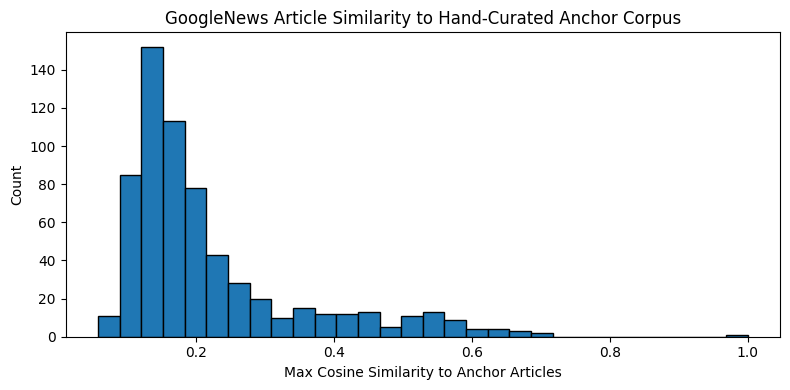

In [32]:
# --- 5. Plot distribution to help pick a threshold ---
# Shows how similar your Google News articles are to the trusted NFL anchor articles
plt.figure(figsize=(8, 4))
plt.hist(all_news_df['max_similarity'], bins=30, edgecolor='black')
plt.xlabel('Max Cosine Similarity to Anchor Articles')
plt.ylabel('Count')
plt.title('GoogleNews Article Similarity to Hand-Curated Anchor Corpus')
plt.tight_layout()
plt.show()

In [33]:
all_news_df['max_similarity'].describe()

count    644.000000
mean       0.219695
std        0.134111
min        0.057567
25%        0.132217
50%        0.173613
75%        0.246427
max        1.000000
Name: max_similarity, dtype: float64

In [47]:
all_news_df[all_news_df['max_similarity'] > 0.14].shape

(446, 12)

In [35]:
all_news_df[all_news_df['max_similarity'] < 0.14].shape

(198, 12)

In [36]:
# --- 6. Filter: keep articles above the threshold ---
# Adjust threshold based on the histogram above — 0.1 is a reasonable starting point
THRESHOLD = 0.14

filtered_news_df = all_news_df[all_news_df['max_similarity'] >= THRESHOLD].reset_index(drop=True)
print(f"After filtering (threshold={THRESHOLD}): {len(filtered_news_df)} articles kept, "
      f"{len(all_news_df) - len(filtered_news_df)} removed")

filtered_news_df[['title', 'max_similarity']].sort_values('max_similarity', ascending=False).head(20)


After filtering (threshold=0.14): 446 articles kept, 198 removed


,title,max_similarity
167,"Resisting Pressure, NFL Players Greet Fans On ...",1.000000
306,"Timeline of Deshaun Watson’s legal troubles, c...",0.713237
138,What to know about the Deshaun Watson controve...,0.689982
269,The NFL responds after a player urges female c...,0.673709
272,Who is Harrison Butker and why is he at the ce...,0.661838
130,Bills Receiver Cole Beasley Ignites Controvers...,0.656706
242,From hotel controversy to NFL superstar: The i...,0.653429
273,NFL bans hip-drop tackle — and it’s already a ...,0.634625
301,The biggest mistake Harrison Butker made in hi...,0.630547
259,NFL ends inquiry of Deshaun Watson in latest s...,0.628043


In [37]:
# Re-transform the filtered news articles using the same vectorizer from the previous cell.This gives us a TF-IDF matrix where each row is a news article and each column is a word weight.
news_matrix_filtered = vectorizer.transform(filtered_news_df['website_text'])

In [38]:
# Compute cosine similarity between every anchor article and every filtered news article.The result is a matrix of shape (n_anchor_articles, n_news_articles). Each value ranges from 0 (completely different) to 1 (identical).
sim_matrix = cosine_similarity(anchor_matrix, news_matrix_filtered)

In [39]:
# For each news article (column), find which anchor article (row) it is most similar to. argmax(axis=0) returns the row index of the highest value in each column.
filtered_news_df['most_similar_anchor_idx'] = sim_matrix.argmax(axis=0)

In [40]:
# Map that index back to a human-readable anchor title using the original dataframe.
filtered_news_df['most_similar_anchor_title'] = filtered_news_df['most_similar_anchor_idx'].map(
    lambda i: test_nfl_df_true.iloc[i]['Event Description'] if i < len(test_nfl_df_true) else "Unknown"
)


In [41]:
# Build short labels for each anchor article so they are readable when printed.
anchor_labels = [
    str(test_nfl_df_true.iloc[i].get('Event Description', f'Anchor {i}'))[:60]
    for i in range(len(anchor_texts))
]

In [42]:
# For each anchor article, print the top 3 most similar GoogleNews articles.
# This helps you verify that the similarity scores make intuitive sense —
# the matched news articles should actually be about the same event or player.
print("Top 3 most similar GoogleNews articles per anchor article:\n")
for i, anchor_label in enumerate(anchor_labels):
    # Get similarity scores between this anchor and all filtered news articles
    anchor_sims = sim_matrix[i, :]
    # argsort() sorts lowest-to-highest, so we take the last 3 and reverse for top-3
    top3_idx = anchor_sims.argsort()[-3:][::-1]

    print(f"Anchor: {anchor_label}")
    for j in top3_idx:
        title = str(filtered_news_df.iloc[j]['title'])[:70]
        score = anchor_sims[j]
        print(f"  {score:.3f}  {title}")
    print()


Top 3 most similar GoogleNews articles per anchor article:

Anchor: Instagram post celebrating July 4th sparked backlash due to 
  0.199  This is why the World Cup 2022 in Qatar is controversial - The Athleti
  0.190  Former NFL Star Boomer Esiason Sparks Controversy With Eileen Gu Comme
  0.153  Trump criticizes NFL over Bad Bunny's 2026 Super Bowl halftime show: W

Anchor: Response to a tweet that praises Texas running back 
  0.576  Sapp’s Hiring at Colorado Met With Harsh Criticism
  0.316  Cris Carter controversy shows an appalling lack of judgment by everyon
  0.238  Shedeur Sanders Racial Bias? NFL Media Stirs Controversy Ahead Of 2025

Anchor: Apologizes after making antisemitic gesture during livestrea
  0.616  Puka Nacua, NFL Release Statements on Stream Controversy
  0.127  Arsenal owner Stan Kroenke forced into $790M settlement after NFL disp
  0.118  The history behind kneeling to protest includes Alabama

Anchor: Wishing everyone a Happy Easter while making jokes of the c

In [43]:
filtered_news_df.head()

,title,desc,date,datetime,link,img,media,site,reporter,website_text,resolved_url,max_similarity,most_similar_anchor_idx,most_similar_anchor_title
0,Roger Goodell breaks silence on controversial ...,NaN,"Jan 30, 2019",2019-01-30,https://news.google.com/read/CBMisgFBVV95cUxPc...,https://news.google.com/api/attachments/CC8iK0...,Yahoo Sports,NaN,By Charles Robinson,Roger Goodell breaks silence on controversial ...,https://sports.yahoo.com/roger-goodell-breaks-...,0.222297,62,NFL fans accussed officials of favoritism towa...
1,The 12 biggest controversies in the NFL's 100-...,NaN,"Sep 18, 2019",2019-09-18,https://news.google.com/read/CBMikgFBVV95cUxQN...,https://news.google.com/api/attachments/CC8iL0...,Business Insider,NaN,By Alexandra Licata,- The NFL has endured many controversies throu...,https://www.businessinsider.com/the-biggest-nf...,0.183864,25,Had disagreements with his then-wife about ret...
2,Uncle Luke Speaks On Jay-Z's NFL Deal Controversy,NaN,"Aug 19, 2019",2019-08-19,https://news.google.com/read/CBMijAFBVV95cUxOL...,https://news.google.com/api/attachments/CC8iL0...,bet.com,NaN,By Diamond Alexis,Uncle Luke Speaks On Jay-Z's NFL Deal Controve...,https://www.bet.com/article/fmac1f/uncle-luke-...,0.152469,48,"With the issues about the TV rights deals, Mer..."
3,The big-time NFL umpire who has a history of c...,NaN,"Jan 27, 2019",2019-01-27,https://news.google.com/read/CBMinwFBVV95cUxPd...,https://news.google.com/api/attachments/CC8iK0...,USA Today,NaN,By Josh Peter,The big-time NFL umpire who has a history of c...,https://www.usatoday.com/story/sports/nfl/2019...,0.155772,62,NFL fans accussed officials of favoritism towa...
4,Saints crushed after controversial no-call hel...,NaN,"Jan 20, 2019",2019-01-20,https://news.google.com/read/CBMiqAFBVV95cUxQN...,https://news.google.com/api/attachments/CC8iL0...,NFL.com,NaN,By Jim Trotter,NEW ORLEANS -- A Saints coach walked slowly th...,https://www.nfl.com/news/saints-crushed-after-...,0.172253,57,Shows frustration about the Saints performance...


In [44]:
filtered_news_df.columns

Index(['title', 'desc', 'date', 'datetime', 'link', 'img', 'media', 'site',
       'reporter', 'website_text', 'resolved_url', 'max_similarity',
       'most_similar_anchor_idx', 'most_similar_anchor_title'],
      dtype='str')

In [45]:
filtered_news_df[['title', 'media', 'max_similarity']].sort_values(ascending=False, by=['max_similarity']).head()

,title,media,max_similarity
167,"Resisting Pressure, NFL Players Greet Fans On ...",i24NEWS,1.000000
306,"Timeline of Deshaun Watson’s legal troubles, c...",The New York Times,0.713237
138,What to know about the Deshaun Watson controve...,Oregon Public Broadcasting - OPB,0.689982
269,The NFL responds after a player urges female c...,NPR,0.673709
272,Who is Harrison Butker and why is he at the ce...,NBC 5 Chicago,0.661838


In [48]:
filtered_news_df.to_csv("filtered_news_df.csv", index=False) # Delete later

### Ollama - use LLM programming to classify interpretable variables (observing diverges and converges)

Use Ollama (3.2) - so can use LLM programmatically

In [12]:
import ollama

response = ollama.chat(
    model='llama3.2',
    messages=[{'role': 'user', 'content': 'Say hello in one sentence.'}]
)
print(response['message']['content'])

Hello!


In [13]:
event_df = test_nfl_df.copy()

In [14]:
all_events = event_df['Event Type'].unique().tolist()
all_events

['Controversy', 'Apology', 'Support', 'Humor', 'Reflection']

In [15]:
event_df[event_df['Event Type'].isna()]

,ID,Player Name,Player Status,Year of Event,Statement Made,Event Description,Platform,Event Type,Media Tone,Post Status,Media Coverage,Sources,URL,Unnamed: 13,Unnamed: 14,website_text


Event types

In [16]:
import ollama

# Build the event list from our actual dataset
event_list = '\n'.join(f'- {g}' for g in sorted(all_events))

def classify_cold_event(row):
    """Zero-shot genre classification — text only, no prior signals."""
    url = str(row.get('URL', ''))
    website_text = str(row.get('website_text', ''))
    if pd.isna(website_text) or len(website_text) < 200:
        return None
    passage = website_text[:2000]

    prompt = f"""You are classifying NFL-related events into event types.

Source URL: {url}

Website Text: {passage}

Classify this event into EXACTLY ONE of the following event types:
{event_list}

Respond with ONLY the event name from the list above. No explanation, no punctuation."""

    try:
        response = ollama.chat(
            model='llama3.2',
            messages=[{'role': 'user', 'content': prompt}]
        )
        return response['message']['content'].strip()
    except Exception as e:
        print(f"Error for {row['title']}: {e}")
        return None

In [17]:
# Run LLM classification
test_nfl_df_true['llm_pred_event'] = test_nfl_df_true.apply(classify_cold_event, axis=1)

In [18]:
y_true = test_nfl_df_true['Event Type']
y_pred = test_nfl_df_true['llm_pred_event']

In [19]:
test_nfl_df_true[['Event Type', 'llm_pred_event']].head(10)

,Event Type,llm_pred_event
0,Controversy,Controversy
1,Controversy,Controversy
2,Apology,Controversy
3,Controversy,Humor
4,Controversy,Controversy
5,Controversy,Controversy
6,Controversy,Controversy
7,Support,Support
8,Controversy,Controversy
9,Humor,Controversy


Some NaN values for llm_pred_event

In [20]:
test_nfl_df_true['llm_pred_event'] = (
    test_nfl_df_true['llm_pred_event']
    .str.strip()
    .str.lower()
)

test_nfl_df_true['Event Type'] = (
    test_nfl_df_true['Event Type']
    .str.strip()
    .str.lower()
)

In [21]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Drop missing predictions
df_eval = test_nfl_df_true.dropna(subset=['llm_pred_event'])

accuracy = accuracy_score(df_eval['Event Type'], df_eval['llm_pred_event'])
print("Accuracy:", accuracy)

print("\nClassification Report:")
print(classification_report(df_eval['Event Type'], df_eval['llm_pred_event']))

print("\nConfusion Matrix:")
print(confusion_matrix(df_eval['Event Type'], df_eval['llm_pred_event']))

Accuracy: 0.676056338028169

Classification Report:
              precision    recall  f1-score   support

     apology       1.00      0.33      0.50         3
 controversy       0.67      0.97      0.80        36
       humor       0.50      0.40      0.44        10
  reflection       0.67      0.67      0.67         6
     support       1.00      0.25      0.40        16

    accuracy                           0.68        71
   macro avg       0.77      0.52      0.56        71
weighted avg       0.74      0.68      0.63        71


Confusion Matrix:
[[ 1  2  0  0  0]
 [ 0 35  1  0  0]
 [ 0  6  4  0  0]
 [ 0  1  1  4  0]
 [ 0  8  2  2  4]]


In [22]:
errors = df_eval[df_eval['Event Type'] != df_eval['llm_pred_event']]

errors[['Event Type', 'llm_pred_event', 'URL']].head(10)

,Event Type,llm_pred_event,URL
2,apology,controversy,https://www.cnn.com/2025/12/18/sport/football-...
3,controversy,humor,https://www.yahoo.com/entertainment/articles/t...
9,humor,controversy,https://sports.yahoo.com/article/panthers-olb-...
16,support,controversy,https://www.yahoo.com/entertainment/celebrity/...
21,support,controversy,https://sports.yahoo.com/articles/ex-nfl-playe...
23,reflection,humor,https://sports.yahoo.com/articles/travis-kelce...
28,support,controversy,https://broncoswire.usatoday.com/story/sports/...
29,support,humor,https://sports.yahoo.com/article/amik-robertso...
34,support,humor,https://sports.yahoo.com/articles/caleb-willia...
35,reflection,controversy,https://www.espn.com/nfl/story/_/id/46932042/s...


In [23]:
df_eval['match'] = df_eval['Event Type'] == df_eval['llm_pred_event']
agreement_rate = df_eval['match'].mean()

print("Agreement rate:", agreement_rate)

Agreement rate: 0.676056338028169


In [24]:
errors['Event Type'].value_counts()

Event Type
support        12
humor           6
apology         2
reflection      2
controversy     1
Name: count, dtype: int64

In [25]:
nfl_df.columns

Index(['ID', 'Player Name', 'Player Status', 'Year of Event', 'Statement Made',
       'Event Description', 'Platform', 'Event Type', 'Media Tone',
       'Post Status', 'Media Coverage', 'Sources', 'URL', 'Unnamed: 13',
       'Unnamed: 14'],
      dtype='str')

Media Tones

In [26]:
media_df_tone = test_nfl_df_true.copy()

In [27]:
all_media_tones = media_df_tone['Media Tone'].unique().tolist()

In [28]:
# Build the media tone list from our actual dataset
media_tones_list = '\n'.join(f'- {g}' for g in sorted(all_media_tones))

def classify_cold_tone(row):
    """Zero-shot genre classification — text only, no prior signals."""
    url = str(row.get('URL', ''))
    website_text = str(row.get('website_text', ''))
    if pd.isna(website_text) or len(website_text) < 200:
        return None
    passage = website_text[:2000]

    prompt = f"""You are classifying NFL-related events into media tones.

Source URL: {url}

Website Text: {passage}

Classify this event into EXACTLY ONE of the following media tones:
{media_tones_list}

Respond with ONLY the media tone from the list above. No explanation, no punctuation."""

    try:
        response = ollama.chat(
            model='llama3.2',
            messages=[{'role': 'user', 'content': prompt}]
        )
        return response['message']['content'].strip()
    except Exception as e:
        print(f"Error for {row['title']}: {e}")
        return None

In [29]:
# Run LLM classification
test_nfl_df_true['llm_pred_tones'] = test_nfl_df_true.apply(classify_cold_tone, axis=1)

In [30]:
y_true = test_nfl_df_true['Media Tone']
y_pred = test_nfl_df_true['llm_pred_tones']

In [31]:
test_nfl_df_true[['Media Tone', 'llm_pred_tones']].head(10)

,Media Tone,llm_pred_tones
0,Negative,Negative
1,Negative,Negative
2,Negative,Negative
3,Mixed,Positive
4,Negative,Negative
5,Negative,Negative
6,Negative,Negative
7,Positive,Positive
8,Mixed,Negative
9,Positive,Positive


In [32]:
test_nfl_df_true['llm_pred_tones'] = (
    test_nfl_df_true['llm_pred_tones']
    .str.strip()
    .str.lower()
)

test_nfl_df_true['Media Tone'] = (
    test_nfl_df_true['Media Tone']
    .str.strip()
    .str.lower()
)


In [33]:
# Drop missing predictions
df_eval = test_nfl_df_true.dropna(subset=['llm_pred_tones'])

accuracy = accuracy_score(df_eval['Media Tone'], df_eval['llm_pred_tones'])
print("Accuracy:", accuracy)

print("\nClassification Report:")
print(classification_report(df_eval['Media Tone'], df_eval['llm_pred_tones']))

print("\nConfusion Matrix:")
print(confusion_matrix(df_eval['Media Tone'], df_eval['llm_pred_tones']))


Accuracy: 0.6338028169014085

Classification Report:
              precision    recall  f1-score   support

       mixed       0.17      0.06      0.09        16
    negative       0.67      0.80      0.73        30
    positive       0.69      0.80      0.74        25

    accuracy                           0.63        71
   macro avg       0.51      0.55      0.52        71
weighted avg       0.56      0.63      0.59        71


Confusion Matrix:
[[ 1  9  6]
 [ 3 24  3]
 [ 2  3 20]]


In [34]:
errors = df_eval[df_eval['Media Tone'] != df_eval['llm_pred_tones']]

errors[['Media Tone', 'llm_pred_tones', 'URL']].head(10)

,Media Tone,llm_pred_tones,URL
3,mixed,positive,https://www.yahoo.com/entertainment/articles/t...
8,mixed,negative,https://www.hindustantimes.com/sports/us-sport...
16,positive,negative,https://www.yahoo.com/entertainment/celebrity/...
19,negative,positive,https://www.usmagazine.com/entertainment/news/...
20,mixed,negative,https://www.yahoo.com/entertainment/celebrity/...
21,mixed,negative,https://sports.yahoo.com/articles/ex-nfl-playe...
22,mixed,negative,https://www.aol.com/articles/former-nfl-qb-rya...
26,negative,mixed,https://www.usmagazine.com/celebrity-news/news...
27,mixed,negative,https://www.nfl.com/news/a-j-brown-let-frustra...
30,positive,negative,https://www.nbcsports.com/nfl/profootballtalk/...


In [35]:
df_eval['match'] = df_eval['Media Tone'] == df_eval['llm_pred_tones']
agreement_rate = df_eval['match'].mean()

print("Agreement rate:", agreement_rate)


Agreement rate: 0.6338028169014085


In [36]:
errors['Media Tone'].value_counts()

Media Tone
mixed       15
negative     6
positive     5
Name: count, dtype: int64

Media Coverage

In [37]:
media_df_coverage = test_nfl_df_true.copy()

In [38]:
all_media_coverages = media_df_coverage['Media Coverage'].unique().tolist()

In [39]:
test_nfl_df_true.columns

Index(['ID', 'Player Name', 'Player Status', 'Year of Event', 'Statement Made',
       'Event Description', 'Platform', 'Event Type', 'Media Tone',
       'Post Status', 'Media Coverage', 'Sources', 'URL', 'website_text',
       'llm_pred_event', 'llm_pred_tones'],
      dtype='str')

In [40]:
import re

def extract_sources(row):
    raw = str(row.get("Sources", ""))

    # split by comma, semicolon, or newline
    parts = re.split(r",|;|\n", raw)

    # clean + normalize
    cleaned = [p.strip().lower() for p in parts if p.strip()]

    # remove duplicates
    return list(set(cleaned))

In [41]:
test_nfl_df_true['sources_list'] = test_nfl_df_true.apply(extract_sources, axis=1)

In [42]:
sources_exploded = test_nfl_df_true.explode("sources_list")

In [43]:
sources_exploded['sources_list'].value_counts().head()

sources_list
yahoo sports    27
espn             9
us weekly        8
people           7
fox news         6
Name: count, dtype: int64

In [44]:
HIGH_TIER = {
    # core sports
    "espn", "yahoo sports", "fox sports", "nbc sports",
    "cbs sports", "sports illustrated", "si", "the athletic",
    "bleacher report",

    # league / official
    "nfl", "nfl com",

    # major news
    "cnn", "cnn sports", "fox news",
    "associated press", "usa today", "washington post",
    "new york times", "nytimes", "the new york times",

    # major media brands
    "nbc news", "cbs news", "bbc",

    # high-reach entertainment (important in your dataset)
    "people"
}

In [45]:
MEDIUM_TIER = {
    "msn", "yahoo news",
    "us weekly", "tmz",
    "new york post", "daily mail",
    "aol", "aol news",
    "outsports", "billboard",
    "vanity fair",
    "sporting news", "athlon sports",
    "yardbarker", "total pro sports",
    "heavy sports", "larry brown sports"
}

In [46]:
def compute_source_strength(source_list):
    score = 0

    for s in source_list:
        if any(h in s for h in HIGH_TIER):
            score += 3
        elif any(m in s for m in MEDIUM_TIER):
            score += 1
        else:
            score -= 1  # unknown / low credibility sources

    return score

In [47]:
def classify_media_coverage_llm(row):

    event_type = row.get("llm_pred_event", "Unknown")
    sources_list = extract_sources(row)
    source_strength = compute_source_strength(sources_list)

    if not sources_list:
        return "Low"  # no sources = low coverage
    
    if event_type is None or event_type == "":
        event_type = "Unknown"

    prompt = f"""
Classify MEDIA VISIBILITY of an NFL event.

You are estimating how visible the event was in the media, based primarily on the influence and credibility of the sources reporting it, rather than just the number of sources.

Inputs:
Event type: {event_type}
Source strength: {source_strength}

Source strength meaning:
- 1–3 → Low visibility (minor influential sources)
- 4–6 → Medium visibility (moderately influential sources)
- 7+ → High visibility (major, highly influential outlets)

Event type guidance:
- Controversy → increases visibility
- Apology → moderate visibility
- Support → moderate visibility
- Reflection → lower visibility
- Humor → low unless covered by influential sources

Task:
Use both the source strength (influence of coverage) and event type to determine overall media visibility.

Return ONLY one word:
High
Medium
Low
Do not include an explanation, but only one word classifying the media coverage (High, Medium, Low)
"""

    response = ollama.chat(
        model="llama3.2",
        messages=[{"role": "user", "content": prompt}]
    )

    return response["message"]["content"].strip()

In [48]:
# Run LLM classification
test_nfl_df_true['llm_pred_coverages'] = test_nfl_df_true.apply(classify_media_coverage_llm, axis=1)

In [49]:
y_true = test_nfl_df_true['Media Coverage']
y_pred = test_nfl_df_true['llm_pred_coverages']

In [50]:
test_nfl_df_true[['Media Coverage', 'llm_pred_coverages']].head(10)

,Media Coverage,llm_pred_coverages
0,High,Medium
1,Medium,Medium
2,High,High
3,High,Medium
4,Medium,High
5,Medium,Medium
6,Medium,High
7,Low,Low
8,Low,Medium
9,Low,Medium


In [51]:
test_nfl_df_true['llm_pred_coverages'] = (
    test_nfl_df_true['llm_pred_coverages']
    .str.strip()
    .str.lower()
)

test_nfl_df_true['Media Coverage'] = (
    test_nfl_df_true['Media Coverage']
    .str.strip()
    .str.lower()
)

In [52]:
# Drop missing predictions
df_eval = test_nfl_df_true.dropna(subset=['llm_pred_coverages'])

accuracy = accuracy_score(df_eval['Media Coverage'], df_eval['llm_pred_coverages'])
print("Accuracy:", accuracy)

print("\nClassification Report:")
print(classification_report(df_eval['Media Coverage'], df_eval['llm_pred_coverages']))

print("\nConfusion Matrix:")
print(confusion_matrix(df_eval['Media Coverage'], df_eval['llm_pred_coverages']))

Accuracy: 0.3888888888888889

Classification Report:
              precision    recall  f1-score   support

        high       0.11      0.44      0.18         9
         low       0.33      0.05      0.09        19
      medium       0.68      0.52      0.59        44

    accuracy                           0.39        72
   macro avg       0.37      0.34      0.29        72
weighted avg       0.52      0.39      0.41        72


Confusion Matrix:
[[ 4  0  5]
 [12  1  6]
 [19  2 23]]


In [53]:
errors = df_eval[df_eval['Media Coverage'] != df_eval['llm_pred_coverages']]

errors[['Media Coverage', 'llm_pred_coverages', 'URL']].head(10)

,Media Coverage,llm_pred_coverages,URL
0,high,medium,https://www.yahoo.com/entertainment/articles/j...
3,high,medium,https://www.yahoo.com/entertainment/articles/t...
4,medium,high,https://sports.yahoo.com/article/deion-sanders...
6,medium,high,https://www.indystar.com/story/sports/nfl/colt...
8,low,medium,https://www.hindustantimes.com/sports/us-sport...
9,low,medium,https://sports.yahoo.com/article/panthers-olb-...
10,medium,low,https://sports.yahoo.com/article/ben-dinucci-n...
11,low,medium,https://www.nfl.com/news/nfl-trailblazer-carl-...
15,medium,high,https://www.espn.com/rugby/story/_/id/29344948...
16,low,high,https://www.yahoo.com/entertainment/celebrity/...


In [54]:
df_eval['match'] = df_eval['Media Coverage'] == df_eval['llm_pred_coverages']
agreement_rate = df_eval['match'].mean()

print("Agreement rate:", agreement_rate)

Agreement rate: 0.3888888888888889


In [55]:
errors['Media Coverage'].value_counts()

Media Coverage
medium    21
low       18
high       5
Name: count, dtype: int64

In [ ]:
test_nfl_df_true.to_csv("test_nfl_df_true.csv",index=False)

: 

#### Where does the interpretative data diverge

In [31]:
nfl_df.isna().sum()

ID                   188
Player Name          188
Player Status        188
Year of Event        188
Statement Made       188
Event Description    188
Platform             188
Event Type           188
Media Tone           188
Post Status          188
Media Coverage       188
Sources              188
URL                  188
Unnamed: 13          263
Unnamed: 14          263
dtype: int64

In [32]:
nfl_df.shape

(263, 15)

In [50]:
nfl_df = nfl_df.drop(columns=['Unnamed: 13', 'Unnamed: 14'])

In [51]:
nfl_df.shape

(263, 13)

In [54]:
nfl_df[nfl_df.isna()].head()

,ID,Player Name,Player Status,Year of Event,Statement Made,Event Description,Platform,Event Type,Media Tone,Post Status,Media Coverage,Sources,URL
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [55]:
nfl_cleaned = nfl_df.dropna()

In [56]:
nfl_cleaned.shape

(75, 13)

In [37]:
test_nfl_df_true = pd.read_csv("test_nfl_df_true.csv")

In [44]:
set(nfl_df.columns).intersection(set(test_nfl_df_true.columns))

{'Event Description',
 'Event Type',
 'ID',
 'Media Coverage',
 'Media Tone',
 'Platform',
 'Player Name',
 'Player Status',
 'Post Status',
 'Sources',
 'Statement Made',
 'URL',
 'Year of Event'}

In [59]:
nfl_cleaned['Player Name']

0       Jason Kelce
1       Warren Sapp
2        Puka Nacua
3      Travis Kelce
4     Deion Sanders
          ...      
70     Dak Prescott
71    George Kittle
72    Aaron Rodgers
73      CeeDee Lamb
74    Justin Fields
Name: Player Name, Length: 75, dtype: str

In [63]:
nfl_cleaned.columns

Index(['ID', 'Player Name', 'Player Status', 'Year of Event', 'Statement Made',
       'Event Description', 'Platform', 'Event Type', 'Media Tone',
       'Post Status', 'Media Coverage', 'Sources', 'URL'],
      dtype='str')

Merging

In [80]:
nfl_cleaned['Event Type'] = (
    nfl_cleaned['Event Type'].
    str.lower()
    .str.strip()
)

In [81]:
nfl_cleaned['Media Tone'] = (
    nfl_cleaned['Media Tone'].
    str.lower()
    .str.strip()
)

In [82]:
nfl_cleaned['Media Coverage'] = (
    nfl_cleaned['Media Coverage'].
    str.lower()
    .str.strip()
)

In [88]:
merged_df = test_nfl_df_true.merge(nfl_cleaned, 
                         on=('ID', 'Player Name', 'Player Status', 'Year of Event', 'Statement Made',
       'Event Description', 'Platform', 'Event Type', 'Media Tone',
       'Post Status', 'Media Coverage', 'Sources', 'URL'),
                         how="left",
                         suffixes=("_manual", "_llm"))

In [89]:
merged_df.columns

Index(['ID', 'Player Name', 'Player Status', 'Year of Event', 'Statement Made',
       'Event Description', 'Platform', 'Event Type', 'Media Tone',
       'Post Status', 'Media Coverage', 'Sources', 'URL', 'website_text',
       'llm_pred_event', 'llm_pred_tones', 'sources_list',
       'llm_pred_coverages'],
      dtype='str')

In [90]:
merged_df.shape

(72, 18)

Basic Agreement Analysis

In [99]:
merged_df['event_type_match'] = (merged_df['Event Type'] == merged_df['llm_pred_event'])

In [100]:
merged_df['event_type_match'].value_counts()

event_type_match
True     48
False    24
Name: count, dtype: int64

In [101]:
merged_df['media_tone_match'] = (merged_df['Media Tone'] == merged_df['llm_pred_tones'])

In [102]:
merged_df['media_tone_match'].value_counts()

media_tone_match
True     45
False    27
Name: count, dtype: int64

In [103]:
merged_df['media_coverage_match'] = (merged_df['Media Coverage'] == merged_df['llm_pred_coverages'])

In [104]:
merged_df['media_coverage_match'].value_counts()

media_coverage_match
False    44
True     28
Name: count, dtype: int64

Overall Agreement Rates

In [105]:
merged_df[[
    "event_type_match",
    "media_tone_match",
    "media_coverage_match"
]].mean()

event_type_match        0.666667
media_tone_match        0.625000
media_coverage_match    0.388889
dtype: float64

Confusion Matrices

In [106]:
pd.crosstab(
    merged_df['Event Type'],
    merged_df['llm_pred_event'],
    normalize="index"
)

llm_pred_event,apology,controversy,humor,reflection,support
Event Type,,,,,
apology,0.333333,0.666667,0.000000,0.000000,0.00
controversy,0.000000,0.972222,0.027778,0.000000,0.00
humor,0.000000,0.600000,0.400000,0.000000,0.00
reflection,0.000000,0.166667,0.166667,0.666667,0.00
support,0.000000,0.500000,0.125000,0.125000,0.25


In [107]:
pd.crosstab(
    merged_df['Media Tone'],
    merged_df['llm_pred_tones'],
    normalize="index"
)

llm_pred_tones,mixed,negative,positive
Media Tone,,,
mixed,0.0625,0.5625,0.375
negative,0.1000,0.8000,0.100
positive,0.0800,0.1200,0.800


In [108]:
pd.crosstab(
    merged_df['Media Coverage'],
    merged_df['llm_pred_coverages'],
    normalize="index"
)

llm_pred_coverages,high,low,medium
Media Coverage,,,
high,0.444444,0.000000,0.555556
low,0.631579,0.052632,0.315789
medium,0.431818,0.045455,0.522727


Visualizations

1. Agreement Bar Chart

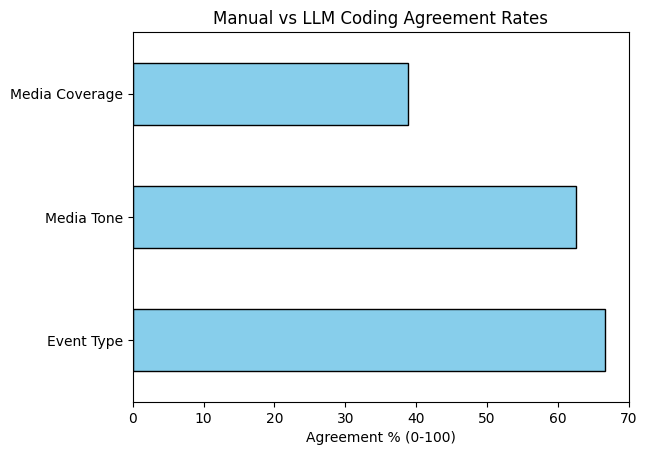

In [118]:
agreement_scores = merged_df[[
    "event_type_match",
    "media_tone_match",
    "media_coverage_match"
]].mean() * 100

agreement_scores.index = ["Event Type", "Media Tone", "Media Coverage"]

agreement_scores.plot(kind="barh", color="skyblue", edgecolor="black")
  
plt.title("Manual vs LLM Coding Agreement Rates")
plt.xlabel("Agreement % (0-100)")
plt.show()

2. Heatmap

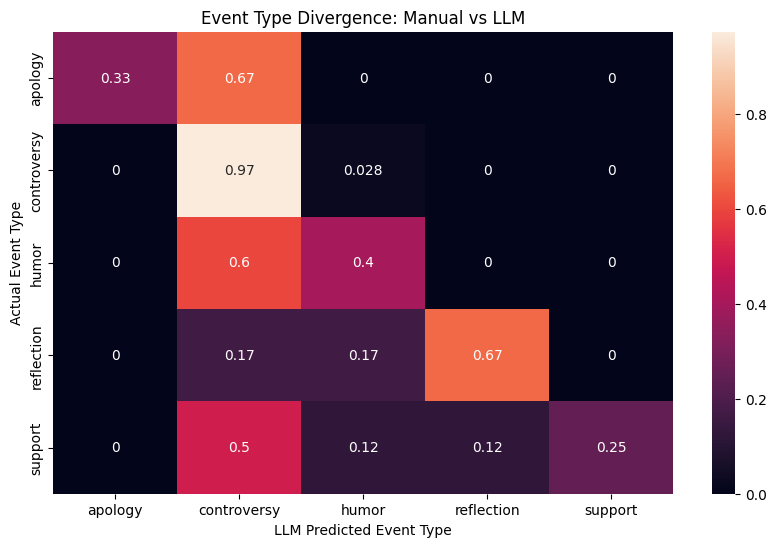

In [186]:
plt.figure(figsize=(10,6))
sns.heatmap(
    pd.crosstab(
        merged_df["Event Type"],
        merged_df["llm_pred_event"],
        normalize="index"
    ),
    annot=True
)
plt.title("Event Type Divergence: Manual vs LLM")
plt.xlabel("LLM Predicted Event Type")
plt.ylabel("Actual Event Type")
plt.show()

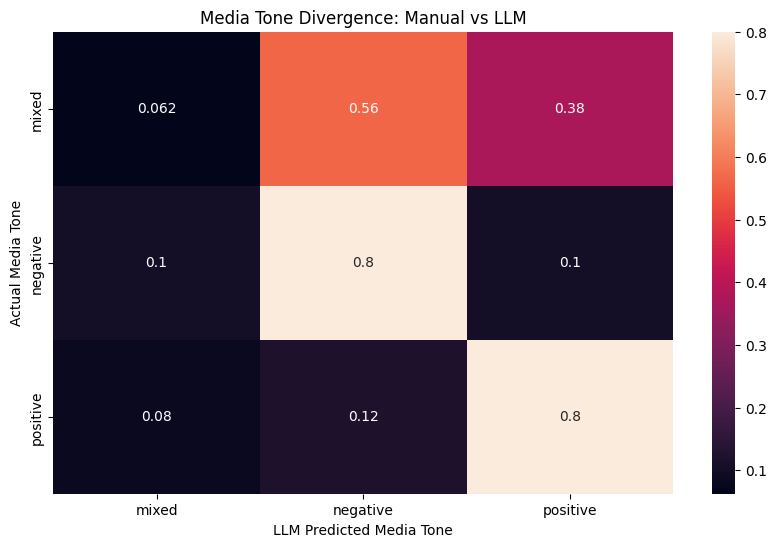

In [187]:
plt.figure(figsize=(10,6))
sns.heatmap(
    pd.crosstab(
        merged_df["Media Tone"],
        merged_df["llm_pred_tones"],
        normalize="index"
    ),
    annot=True
)
plt.title("Media Tone Divergence: Manual vs LLM")
plt.xlabel("LLM Predicted Media Tone")
plt.ylabel("Actual Media Tone")
plt.show()

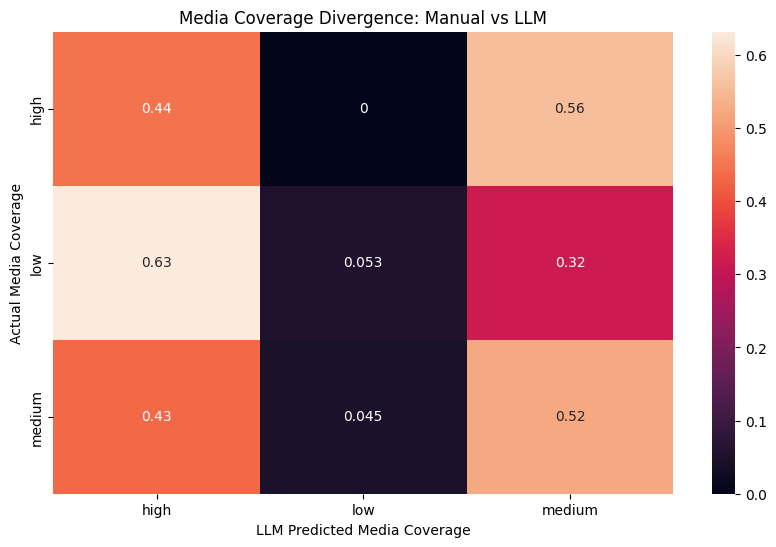

In [190]:
plt.figure(figsize=(10,6))
sns.heatmap(
    pd.crosstab(
        merged_df["Media Coverage"],
        merged_df["llm_pred_coverages"],
        normalize="index"
    ),
    annot=True
)
plt.title("Media Coverage Divergence: Manual vs LLM")
plt.xlabel("LLM Predicted Media Coverage")
plt.ylabel("Actual Media Coverage")
plt.show()

Using Website Text Influence

Hypothesis: LLM labels are more sensitive to textual sentiment than human interpretation.

-1: very negative

0: neutral

1: very positive

In [124]:
from textblob import TextBlob

merged_df["text_sentiment"] = merged_df["website_text"].apply(
    lambda x: TextBlob(str(x)).sentiment.polarity
)

In [130]:
merged_df.groupby("Event Type")["text_sentiment"].mean()

Event Type
apology       -0.041753
controversy    0.086847
humor          0.115461
reflection     0.126589
support        0.115551
Name: text_sentiment, dtype: float64

In [131]:
merged_df.groupby("llm_pred_event")["text_sentiment"].mean()

llm_pred_event
apology        0.107328
controversy    0.089979
humor          0.121801
reflection     0.099174
support        0.123831
Name: text_sentiment, dtype: float64

In [126]:
merged_df.groupby("Media Tone")["text_sentiment"].mean()

Media Tone
mixed       0.083910
negative    0.085416
positive    0.114423
Name: text_sentiment, dtype: float64

In [127]:
merged_df.groupby("llm_pred_tones")["text_sentiment"].mean()

llm_pred_tones
mixed       0.058286
negative    0.079919
positive    0.124973
Name: text_sentiment, dtype: float64

Are LLMs more "textual" than humans?

Does LLM over-detect controversy? 

Does media framing influence LLM more than human coding?

In [128]:
merged_df["event_type_divergence"] = (
    merged_df["Event Type"] != merged_df["llm_pred_event"]
).astype(int)

In [129]:
merged_df.groupby("Player Name")["event_type_divergence"].mean().sort_values(ascending=False)

Player Name
Amik Robertson    1.0
Cooper Kupp       1.0
CeeDee Lamb       1.0
Cam Akers         1.0
Caleb Williams    1.0
                 ... 
Tony Dungy        0.0
Tua Tagovailoa    0.0
Tyreek Hill       0.0
Vernon Davis      0.0
Warren Sapp       0.0
Name: event_type_divergence, Length: 62, dtype: float64

Goal: Use LLM to classify blind based on the url, website_text (the non-interpretable variables) - see if there are any converges or diverges from my classification as I would be the ground truth. 
- Use this source as a resource: https://cultureasdata-uiuc.github.io/is310-spring-2026/materials/interpreting-communicating-humanities-data/04-advanced-computational-methods.html#llm-classification-with-ollama

(Goal is to get this part done by Tuesday to see if this is feasible to scale up)

### Ollama - use LLM programming to classify interpretable variables (Google News)

In [56]:
filtered_news_df = pd.read_csv("filtered_news_df.csv")

In [57]:
filtered_news_df.head()

,title,desc,date,datetime,link,img,media,site,reporter,website_text,resolved_url,max_similarity,most_similar_anchor_idx,most_similar_anchor_title
0,Roger Goodell breaks silence on controversial ...,NaN,"Jan 30, 2019",2019-01-30,https://news.google.com/read/CBMisgFBVV95cUxPc...,https://news.google.com/api/attachments/CC8iK0...,Yahoo Sports,NaN,By Charles Robinson,Roger Goodell breaks silence on controversial ...,https://sports.yahoo.com/roger-goodell-breaks-...,0.222297,62,NFL fans accussed officials of favoritism towa...
1,The 12 biggest controversies in the NFL's 100-...,NaN,"Sep 18, 2019",2019-09-18,https://news.google.com/read/CBMikgFBVV95cUxQN...,https://news.google.com/api/attachments/CC8iL0...,Business Insider,NaN,By Alexandra Licata,- The NFL has endured many controversies throu...,https://www.businessinsider.com/the-biggest-nf...,0.183864,25,Had disagreements with his then-wife about ret...
2,Uncle Luke Speaks On Jay-Z's NFL Deal Controversy,NaN,"Aug 19, 2019",2019-08-19,https://news.google.com/read/CBMijAFBVV95cUxOL...,https://news.google.com/api/attachments/CC8iL0...,bet.com,NaN,By Diamond Alexis,Uncle Luke Speaks On Jay-Z's NFL Deal Controve...,https://www.bet.com/article/fmac1f/uncle-luke-...,0.152469,48,"With the issues about the TV rights deals, Mer..."
3,The big-time NFL umpire who has a history of c...,NaN,"Jan 27, 2019",2019-01-27,https://news.google.com/read/CBMinwFBVV95cUxPd...,https://news.google.com/api/attachments/CC8iK0...,USA Today,NaN,By Josh Peter,The big-time NFL umpire who has a history of c...,https://www.usatoday.com/story/sports/nfl/2019...,0.155772,62,NFL fans accussed officials of favoritism towa...
4,Saints crushed after controversial no-call hel...,NaN,"Jan 20, 2019",2019-01-20,https://news.google.com/read/CBMiqAFBVV95cUxQN...,https://news.google.com/api/attachments/CC8iL0...,NFL.com,NaN,By Jim Trotter,NEW ORLEANS -- A Saints coach walked slowly th...,https://www.nfl.com/news/saints-crushed-after-...,0.172253,57,Shows frustration about the Saints performance...


In [58]:
filtered_news_df.shape

(446, 14)

Event Types

In [59]:
filtered_news_df.shape

(446, 14)

In [60]:
test_df = filtered_news_df.head()

In [91]:
test_df['Event Type'] = test_df.apply(classify_cold_event, axis=1)

In [92]:
test_df['Event Type'].value_counts()

Event Type
Controversy    5
Name: count, dtype: int64

Since there are 446 entries, let's try paritioning into four different sections.

In [97]:
filtered_news_df.head(6)

,title,desc,date,datetime,link,img,media,site,reporter,website_text,resolved_url,max_similarity,most_similar_anchor_idx,most_similar_anchor_title,Event Type
0,Roger Goodell breaks silence on controversial ...,NaN,"Jan 30, 2019",2019-01-30,https://news.google.com/read/CBMisgFBVV95cUxPc...,https://news.google.com/api/attachments/CC8iK0...,Yahoo Sports,NaN,By Charles Robinson,Roger Goodell breaks silence on controversial ...,https://sports.yahoo.com/roger-goodell-breaks-...,0.221795,63,NFL fans accussed officials of favoritism towa...,Negative
1,The 12 biggest controversies in the NFL's 100-...,NaN,"Sep 18, 2019",2019-09-18,https://news.google.com/read/CBMikgFBVV95cUxQN...,https://news.google.com/api/attachments/CC8iL0...,Business Insider,NaN,By Alexandra Licata,- The NFL has endured many controversies throu...,https://www.businessinsider.com/the-biggest-nf...,0.184071,25,Had disagreements with his then-wife about ret...,Mixed
2,Uncle Luke Speaks On Jay-Z's NFL Deal Controversy,NaN,"Aug 19, 2019",2019-08-19,https://news.google.com/read/CBMijAFBVV95cUxOL...,https://news.google.com/api/attachments/CC8iL0...,bet.com,NaN,By Diamond Alexis,Uncle Luke Speaks On Jay-Z's NFL Deal Controve...,https://www.bet.com/article/fmac1f/uncle-luke-...,0.152431,48,"With the issues about the TV rights deals, Mer...",Positive
3,The controversy behind custom cleats in the NFL,NaN,"Nov 4, 2019",2019-11-04,https://news.google.com/read/CBMiwwFBVV95cUxOe...,https://news.google.com/api/attachments/CC8iJ0...,kare11.com,NaN,By Adrienne Broaddus,MINNEAPOLIS — The NFL has been called the no f...,https://www.kare11.com/article/sports/the-cont...,0.145210,60,Shares an encouraging message to draft prospec...,Mixed
4,The big-time NFL umpire who has a history of c...,NaN,"Jan 27, 2019",2019-01-27,https://news.google.com/read/CBMinwFBVV95cUxPd...,https://news.google.com/api/attachments/CC8iK0...,USA Today,NaN,By Josh Peter,The big-time NFL umpire who has a history of c...,https://www.usatoday.com/story/sports/nfl/2019...,0.155198,63,NFL fans accussed officials of favoritism towa...,Positive
5,Saints crushed after controversial no-call hel...,NaN,"Jan 20, 2019",2019-01-20,https://news.google.com/read/CBMiqAFBVV95cUxQN...,https://news.google.com/api/attachments/CC8iL0...,NFL.com,NaN,By Jim Trotter,NEW ORLEANS -- A Saints coach walked slowly th...,https://www.nfl.com/news/saints-crushed-after-...,0.172317,57,Shows frustration about the Saints performance...,Negative


In [94]:
test_df_new = filtered_news_df.loc[:5]

In [95]:
test_df_new

,title,desc,date,datetime,link,img,media,site,reporter,website_text,resolved_url,max_similarity,most_similar_anchor_idx,most_similar_anchor_title,Event Type
0,Roger Goodell breaks silence on controversial ...,NaN,"Jan 30, 2019",2019-01-30,https://news.google.com/read/CBMisgFBVV95cUxPc...,https://news.google.com/api/attachments/CC8iK0...,Yahoo Sports,NaN,By Charles Robinson,Roger Goodell breaks silence on controversial ...,https://sports.yahoo.com/roger-goodell-breaks-...,0.221795,63,NFL fans accussed officials of favoritism towa...,Negative
1,The 12 biggest controversies in the NFL's 100-...,NaN,"Sep 18, 2019",2019-09-18,https://news.google.com/read/CBMikgFBVV95cUxQN...,https://news.google.com/api/attachments/CC8iL0...,Business Insider,NaN,By Alexandra Licata,- The NFL has endured many controversies throu...,https://www.businessinsider.com/the-biggest-nf...,0.184071,25,Had disagreements with his then-wife about ret...,Mixed
2,Uncle Luke Speaks On Jay-Z's NFL Deal Controversy,NaN,"Aug 19, 2019",2019-08-19,https://news.google.com/read/CBMijAFBVV95cUxOL...,https://news.google.com/api/attachments/CC8iL0...,bet.com,NaN,By Diamond Alexis,Uncle Luke Speaks On Jay-Z's NFL Deal Controve...,https://www.bet.com/article/fmac1f/uncle-luke-...,0.152431,48,"With the issues about the TV rights deals, Mer...",Positive
3,The controversy behind custom cleats in the NFL,NaN,"Nov 4, 2019",2019-11-04,https://news.google.com/read/CBMiwwFBVV95cUxOe...,https://news.google.com/api/attachments/CC8iJ0...,kare11.com,NaN,By Adrienne Broaddus,MINNEAPOLIS — The NFL has been called the no f...,https://www.kare11.com/article/sports/the-cont...,0.145210,60,Shares an encouraging message to draft prospec...,Mixed
4,The big-time NFL umpire who has a history of c...,NaN,"Jan 27, 2019",2019-01-27,https://news.google.com/read/CBMinwFBVV95cUxPd...,https://news.google.com/api/attachments/CC8iK0...,USA Today,NaN,By Josh Peter,The big-time NFL umpire who has a history of c...,https://www.usatoday.com/story/sports/nfl/2019...,0.155198,63,NFL fans accussed officials of favoritism towa...,Positive
5,Saints crushed after controversial no-call hel...,NaN,"Jan 20, 2019",2019-01-20,https://news.google.com/read/CBMiqAFBVV95cUxQN...,https://news.google.com/api/attachments/CC8iL0...,NFL.com,NaN,By Jim Trotter,NEW ORLEANS -- A Saints coach walked slowly th...,https://www.nfl.com/news/saints-crushed-after-...,0.172317,57,Shows frustration about the Saints performance...,Negative


In [98]:
test_df_new['Event Type'] = test_df_new.apply(classify_cold_event, axis=1)

In [101]:
test_df_new['Event Type']

0    Controversy
1    Controversy
2    Controversy
3    Controversy
4    Controversy
5    Controversy
Name: Event Type, dtype: str

In [61]:
filtered_news_parition_1 = filtered_news_df.loc[:100]

In [62]:
filtered_news_parition_1.shape

(101, 14)

In [64]:
filtered_news_parition_1['Event Type'] = filtered_news_parition_1.apply(classify_cold_event, axis=1)

In [65]:
filtered_news_parition_1['Event Type'].value_counts()

Event Type
Controversy    96
Reflection      3
Apology         2
Name: count, dtype: int64

In [72]:
filtered_news_parition_2 = filtered_news_df.iloc[101:201]

In [74]:
filtered_news_parition_2.shape

(100, 14)

In [75]:
filtered_news_parition_2['Event Type'] = filtered_news_parition_2.apply(classify_cold_event, axis=1)

In [76]:
filtered_news_parition_2['Event Type'].value_counts()

Event Type
Controversy    97
Reflection      1
Humor           1
Name: count, dtype: int64

In [77]:
filtered_news_parition_2.to_csv("filtered_news_df_2.csv", index=False)

In [78]:
filtered_news_parition_3 = filtered_news_df.iloc[201:324]

In [79]:
filtered_news_parition_3['Event Type'] = filtered_news_parition_3.apply(classify_cold_event, axis=1)

In [80]:
filtered_news_parition_3['Event Type'].value_counts()

Event Type
Controversy    119
Support          2
Reflection       2
Name: count, dtype: int64

In [81]:
filtered_news_parition_3.to_csv("filtered_news_df_3.csv", index=False)

In [ ]:
filtered_news_parition_4 = filtered_news_df.iloc[324:]

In [96]:
filtered_news_parition_4.shape

(122, 14)

In [84]:
filtered_news_parition_4['Event Type'] = filtered_news_parition_4.apply(classify_cold_event, axis=1)

In [119]:
filtered_news_parition_4['Event Type'].value_counts()

Event Type
Controversy    120
Support          1
Reflection       1
Name: count, dtype: int64

In [86]:
filtered_news_parition_4.to_csv("filtered_news_df_4.csv", index=False)

In [120]:
filtered_news_df.shape

(446, 14)

In [125]:
filtered_news_parition_1.shape[0] + filtered_news_parition_2.shape[0] + filtered_news_parition_3.shape[0] + filtered_news_parition_4.shape[0]

446

In [155]:
filtered_news_test = pd.concat([filtered_news_parition_1, filtered_news_parition_2, filtered_news_parition_3, filtered_news_parition_4], join='outer', ignore_index=False)

In [156]:
filtered_news_test.shape

(446, 15)

In [157]:
filtered_news_test[filtered_news_test['Event Type'].isna()]

,title,desc,date,datetime,link,img,media,site,reporter,website_text,resolved_url,max_similarity,most_similar_anchor_idx,most_similar_anchor_title,Event Type
167,"Resisting Pressure, NFL Players Greet Fans On ...",NaN,"Jun 22, 2022",2022-06-22,https://news.google.com/read/CBMieEFVX3lxTE82R...,https://news.google.com/api/attachments/CC8iK0...,i24NEWS,NaN,NaN,You have to enable JavaScript to run this app.,https://www.i24news.tv/en/news/israel/sport/13...,1.0,12,"Tweets about anti-semitic tropes, impling that...",NaN


Looking at the url and website text of the entry with the missing Event Type, I noticed that it isn't reflecting an actual news coverage of an NFL event, so I will just remove this entry from the entire dataframe. 

In [159]:
filtered_news_test = filtered_news_test.dropna(subset=['Event Type'])

In [160]:
filtered_news_test.shape

(445, 15)

In [161]:
filtered_news_test['Event Type'].value_counts()

Event Type
Controversy    432
Reflection       7
Support          3
Apology          2
Humor            1
Name: count, dtype: int64

In [162]:
filtered_news_df = filtered_news_test.copy()

In [ ]:
filtered_news_df.to_csv("filtered_news_df.csv", index=False) # saving each time

Media Tones

In [168]:
filtered_news_df = filtered_news_df.reset_index()
filtered_news_df.head()

,level_0,index,title,desc,date,datetime,link,img,media,site,reporter,website_text,resolved_url,max_similarity,most_similar_anchor_idx,most_similar_anchor_title,Event Type
0,0,0,Roger Goodell breaks silence on controversial ...,NaN,"Jan 30, 2019",2019-01-30,https://news.google.com/read/CBMisgFBVV95cUxPc...,https://news.google.com/api/attachments/CC8iK0...,Yahoo Sports,NaN,By Charles Robinson,Roger Goodell breaks silence on controversial ...,https://sports.yahoo.com/roger-goodell-breaks-...,0.222297,62,NFL fans accussed officials of favoritism towa...,Controversy
1,1,1,The 12 biggest controversies in the NFL's 100-...,NaN,"Sep 18, 2019",2019-09-18,https://news.google.com/read/CBMikgFBVV95cUxQN...,https://news.google.com/api/attachments/CC8iL0...,Business Insider,NaN,By Alexandra Licata,- The NFL has endured many controversies throu...,https://www.businessinsider.com/the-biggest-nf...,0.183864,25,Had disagreements with his then-wife about ret...,Controversy
2,2,2,Uncle Luke Speaks On Jay-Z's NFL Deal Controversy,NaN,"Aug 19, 2019",2019-08-19,https://news.google.com/read/CBMijAFBVV95cUxOL...,https://news.google.com/api/attachments/CC8iL0...,bet.com,NaN,By Diamond Alexis,Uncle Luke Speaks On Jay-Z's NFL Deal Controve...,https://www.bet.com/article/fmac1f/uncle-luke-...,0.152469,48,"With the issues about the TV rights deals, Mer...",Controversy
3,3,3,The big-time NFL umpire who has a history of c...,NaN,"Jan 27, 2019",2019-01-27,https://news.google.com/read/CBMinwFBVV95cUxPd...,https://news.google.com/api/attachments/CC8iK0...,USA Today,NaN,By Josh Peter,The big-time NFL umpire who has a history of c...,https://www.usatoday.com/story/sports/nfl/2019...,0.155772,62,NFL fans accussed officials of favoritism towa...,Controversy
4,4,4,Saints crushed after controversial no-call hel...,NaN,"Jan 20, 2019",2019-01-20,https://news.google.com/read/CBMiqAFBVV95cUxQN...,https://news.google.com/api/attachments/CC8iL0...,NFL.com,NaN,By Jim Trotter,NEW ORLEANS -- A Saints coach walked slowly th...,https://www.nfl.com/news/saints-crushed-after-...,0.172253,57,Shows frustration about the Saints performance...,Controversy


In [170]:
filtered_news_df = filtered_news_df.drop(columns=['level_0'])

In [171]:
filtered_news_df.columns

Index(['index', 'title', 'desc', 'date', 'datetime', 'link', 'img', 'media',
       'site', 'reporter', 'website_text', 'resolved_url', 'max_similarity',
       'most_similar_anchor_idx', 'most_similar_anchor_title', 'Event Type'],
      dtype='str')

In [172]:
filtered_news_parition_1 = filtered_news_df.loc[:100]

In [179]:
filtered_news_parition_1['Media Tone'] = filtered_news_parition_1.apply(classify_cold_tone, axis=1)

In [181]:
filtered_news_parition_1['Media Tone'].value_counts()

Media Tone
Negative    72
Positive    14
Mixed       14
Neutral      1
Name: count, dtype: int64

In [182]:
filtered_news_parition_1.to_csv("filtered_news_df_1.csv", index=False)

In [183]:
filtered_news_parition_2 = filtered_news_df.iloc[101:201]

In [185]:
filtered_news_parition_2['Media Tone'] = filtered_news_parition_2.apply(classify_cold_tone, axis=1)

In [186]:
filtered_news_parition_2['Media Tone'].value_counts()

Media Tone
Negative    70
Positive    20
Mixed       10
Name: count, dtype: int64

In [187]:
filtered_news_parition_2.to_csv("filtered_news_df_2.csv", index=False)

In [188]:
filtered_news_parition_3 = filtered_news_df.iloc[201:324]

In [189]:
filtered_news_parition_3['Media Tone'] = filtered_news_parition_3.apply(classify_cold_tone, axis=1)

In [190]:
filtered_news_parition_3['Media Tone'].value_counts()

Media Tone
Negative    78
Positive    31
Mixed       13
Neutral      1
Name: count, dtype: int64

In [191]:
filtered_news_parition_3.to_csv("filtered_news_df_3.csv", index=False)

In [192]:
filtered_news_parition_4 = filtered_news_df.iloc[324:]

In [193]:
filtered_news_parition_4['Media Tone'] = filtered_news_parition_4.apply(classify_cold_tone, axis=1)

In [194]:
filtered_news_parition_4['Media Tone'].value_counts()

Media Tone
Negative    74
Positive    36
Mixed       10
Neutral      1
Name: count, dtype: int64

In [196]:
filtered_news_parition_4.to_csv("filtered_news_df_4.csv", index=False)

In [197]:
filtered_news_parition_1.shape[0] + filtered_news_parition_2.shape[0] + filtered_news_parition_3.shape[0] + filtered_news_parition_4.shape[0]

445

In [198]:
filtered_news_test = pd.concat([filtered_news_parition_1, filtered_news_parition_2, filtered_news_parition_3, filtered_news_parition_4], join='outer', ignore_index=False)

In [200]:
filtered_news_test['Media Tone'].isna().sum()

np.int64(0)

In [201]:
filtered_news_df = filtered_news_test.copy()

In [202]:
filtered_news_df.to_csv("filtered_news_df.csv", index=False) # saving each time

Media Coverages

Revent the previous functions for media coverage

In [221]:
def extract_sources(row):
    raw = str(row.get("media", ""))

    # split by comma, semicolon, or newline
    parts = re.split(r",|;|\n", raw)

    # clean + normalize
    cleaned = [p.strip().lower() for p in parts if p.strip()]

    # remove duplicates
    return list(set(cleaned))

In [222]:
filtered_news_df['sources_list'] = filtered_news_df.apply(extract_sources, axis=1)

In [224]:
filtered_news_df['sources_list'].value_counts().head()

sources_list
[espn]                  50
[yahoo sports]          44
[the new york times]    22
[usa today]             18
[new york post]         18
Name: count, dtype: int64

In [225]:
# Revised
def classify_media_coverage_llm(row):

    event_type = row.get("Event Type", "Unknown")
    sources_list = extract_sources(row)
    source_strength = compute_source_strength(sources_list)

    if not sources_list:
        return "Low"  # no sources = low coverage
    
    if event_type is None or event_type == "":
        event_type = "Unknown"

    prompt = f"""
Classify MEDIA VISIBILITY of an NFL event.

You are estimating how visible the event was in the media, based primarily on the influence and credibility of the sources reporting it, rather than just the number of sources.

Inputs:
Event type: {event_type}
Source strength: {source_strength}

Source strength meaning:
- 1–3 → Low visibility (minor influential sources)
- 4–6 → Medium visibility (moderately influential sources)
- 7+ → High visibility (major, highly influential outlets)

Event type guidance:
- Controversy → increases visibility
- Apology → moderate visibility
- Support → moderate visibility
- Reflection → lower visibility
- Humor → low unless covered by influential sources

Task:
Use both the source strength (influence of coverage) and event type to determine overall media visibility.

Return ONLY one word:
High
Medium
Low
Do not include an explanation, but only one word classifying the media coverage (High, Medium, Low)
"""

    response = ollama.chat(
        model="llama3.2",
        messages=[{"role": "user", "content": prompt}]
    )

    return response["message"]["content"].strip()

In [226]:
filtered_news_df['media'].isna().sum()

np.int64(0)

In [227]:
filtered_news_df.columns

Index(['index', 'title', 'desc', 'date', 'datetime', 'link', 'img', 'media',
       'site', 'reporter', 'website_text', 'resolved_url', 'max_similarity',
       'most_similar_anchor_idx', 'most_similar_anchor_title', 'Event Type',
       'Media Tone', 'sources_list'],
      dtype='str')

In [228]:
test_df = filtered_news_df.head()

In [232]:
test_df['Media Coverage'] = test_df.apply(classify_media_coverage_llm, axis=1)

In [233]:
test_df['Media Coverage'].value_counts()

Media Coverage
High      3
Medium    2
Name: count, dtype: int64

In [237]:
filtered_news_df['Media Coverage'] = filtered_news_df.apply(classify_media_coverage_llm, axis=1)

In [238]:
filtered_news_df['Media Coverage'].value_counts()

Media Coverage
Medium    215
High      205
Low        25
Name: count, dtype: int64

In [239]:
filtered_news_df.to_csv("filtered_news_df.csv", index=False) # final

#### Combine Datasets to get Final Dataset

In [132]:
filtered_news_df = pd.read_csv("filtered_news_df.csv")

In [133]:
filtered_news_df.columns

Index(['index', 'title', 'desc', 'date', 'datetime', 'link', 'img', 'media',
       'site', 'reporter', 'website_text', 'resolved_url', 'max_similarity',
       'most_similar_anchor_idx', 'most_similar_anchor_title', 'Event Type',
       'Media Tone', 'sources_list', 'Media Coverage'],
      dtype='str')

In [134]:
nfl_df.isna().sum()

ID                   188
Player Name          188
Player Status        188
Year of Event        188
Statement Made       188
Event Description    188
Platform             188
Event Type           188
Media Tone           188
Post Status          188
Media Coverage       188
Sources              188
URL                  188
dtype: int64

In [135]:
nfl_df = nfl_df.drop(columns=['Unnamed: 13', 'Unnamed: 14'])

KeyError: "['Unnamed: 13', 'Unnamed: 14'] not found in axis"

In [136]:
nfl_df.isna().sum().head()

ID                188
Player Name       188
Player Status     188
Year of Event     188
Statement Made    188
dtype: int64

In [137]:
nfl_cleaned = nfl_df.dropna()

In [138]:
nfl_cleaned.shape

(75, 13)

In [139]:
filtered_news_df.shape[0] + nfl_cleaned.shape[0]

520

In [140]:
filtered_news_df.columns

Index(['index', 'title', 'desc', 'date', 'datetime', 'link', 'img', 'media',
       'site', 'reporter', 'website_text', 'resolved_url', 'max_similarity',
       'most_similar_anchor_idx', 'most_similar_anchor_title', 'Event Type',
       'Media Tone', 'sources_list', 'Media Coverage'],
      dtype='str')

In [141]:
filtered_news_df.head()

,index,title,desc,date,datetime,link,img,media,site,reporter,website_text,resolved_url,max_similarity,most_similar_anchor_idx,most_similar_anchor_title,Event Type,Media Tone,sources_list,Media Coverage
0,0,Roger Goodell breaks silence on controversial ...,NaN,"Jan 30, 2019",2019-01-30,https://news.google.com/read/CBMisgFBVV95cUxPc...,https://news.google.com/api/attachments/CC8iK0...,Yahoo Sports,NaN,By Charles Robinson,Roger Goodell breaks silence on controversial ...,https://sports.yahoo.com/roger-goodell-breaks-...,0.222297,62,NFL fans accussed officials of favoritism towa...,Controversy,Negative,['yahoo sports'],Medium
1,1,The 12 biggest controversies in the NFL's 100-...,NaN,"Sep 18, 2019",2019-09-18,https://news.google.com/read/CBMikgFBVV95cUxQN...,https://news.google.com/api/attachments/CC8iL0...,Business Insider,NaN,By Alexandra Licata,- The NFL has endured many controversies throu...,https://www.businessinsider.com/the-biggest-nf...,0.183864,25,Had disagreements with his then-wife about ret...,Controversy,Negative,['business insider'],Medium
2,2,Uncle Luke Speaks On Jay-Z's NFL Deal Controversy,NaN,"Aug 19, 2019",2019-08-19,https://news.google.com/read/CBMijAFBVV95cUxOL...,https://news.google.com/api/attachments/CC8iL0...,bet.com,NaN,By Diamond Alexis,Uncle Luke Speaks On Jay-Z's NFL Deal Controve...,https://www.bet.com/article/fmac1f/uncle-luke-...,0.152469,48,"With the issues about the TV rights deals, Mer...",Controversy,Positive,['bet.com'],Medium
3,3,The big-time NFL umpire who has a history of c...,NaN,"Jan 27, 2019",2019-01-27,https://news.google.com/read/CBMinwFBVV95cUxPd...,https://news.google.com/api/attachments/CC8iK0...,USA Today,NaN,By Josh Peter,The big-time NFL umpire who has a history of c...,https://www.usatoday.com/story/sports/nfl/2019...,0.155772,62,NFL fans accussed officials of favoritism towa...,Controversy,Negative,['usa today'],Medium
4,4,Saints crushed after controversial no-call hel...,NaN,"Jan 20, 2019",2019-01-20,https://news.google.com/read/CBMiqAFBVV95cUxQN...,https://news.google.com/api/attachments/CC8iL0...,NFL.com,NaN,By Jim Trotter,NEW ORLEANS -- A Saints coach walked slowly th...,https://www.nfl.com/news/saints-crushed-after-...,0.172253,57,Shows frustration about the Saints performance...,Controversy,Negative,['nfl.com'],High


In [142]:
filtered_news_cleaned = filtered_news_df.drop(columns=['desc', 'site'])

In [143]:
nfl_cleaned.columns

Index(['ID', 'Player Name', 'Player Status', 'Year of Event', 'Statement Made',
       'Event Description', 'Platform', 'Event Type', 'Media Tone',
       'Post Status', 'Media Coverage', 'Sources', 'URL'],
      dtype='str')

In [144]:
type(filtered_news_cleaned['datetime'])

pandas.Series

In [145]:
filtered_news_cleaned["datetime"] = pd.to_datetime(
    filtered_news_cleaned["datetime"],
    errors="coerce"
)

In [146]:
filtered_news_cleaned['Year of Event'] = filtered_news_cleaned['datetime'].dt.year

In [147]:
filtered_news_cleaned['Year of Event'].value_counts()

Year of Event
2025    85
2024    74
2023    57
2019    52
2022    50
2021    43
2020    42
2026    42
Name: count, dtype: int64

In the filtered dataset, there is no Player Name, Player Status, Year of Event, Statement Made, Event Description, Platform, and Post Status. 

In this case, I will try to get data on these variables.

This would be a limitation as there will be missing values of some entries that would be kept as the interpretative variables are viewed more necessary for this assignment, though the other variables would aid in further understanding the idea of culture in data. For example, understanding if a player's involvement outside of the field garnter more attention to the event, etc. This could be a "next steps" situation.

Player's Name

In [148]:
import spacy
nlp = spacy.load("en_core_web_sm")

In [149]:
def extract_person_entities(title):

    if pd.isna(title):
        return []

    doc = nlp(str(title))

    people = [
        ent.text.strip()
        for ent in doc.ents
        if ent.label_ == "PERSON"
    ]

    # Remove duplicates
    people = list(dict.fromkeys(people))

    return people

In [150]:
filtered_news_cleaned["person_candidates"] = (
    filtered_news_cleaned["title"]
    .apply(extract_person_entities)
)

In [151]:
filtered_news_cleaned['person_candidates']

0          [Roger Goodell]
1                       []
2      [Uncle Luke Speaks]
3                       []
4                       []
              ...         
440            [NFL Draft]
441     [Cleveland Browns]
442            [Eagles QB]
443          [Mike Vrabel]
444                     []
Name: person_candidates, Length: 445, dtype: object

In [152]:
filtered_news_cleaned["Player Name"] = (
    filtered_news_cleaned["person_candidates"]
    .apply(lambda x: x[0] if len(x) > 0 else None)
)

In [153]:
filtered_news_cleaned['Player Name'].isna().sum()

np.int64(197)

In [154]:
filtered_news_cleaned['Player Name'].value_counts().head()

Player Name
Harrison Butker     8
Tom Brady           7
Roger Goodell       6
Antonio Brown       6
Colin Kaepernick    5
Name: count, dtype: int64

Player Status

In [155]:
player_status_df = ["Playing", "Retired", "Free Agenet"]

In [156]:
player_status_dict = dict(
    zip(
        nfl_cleaned["Player Name"].str.strip(),
        nfl_cleaned["Player Status"]
    )
)

In [157]:
filtered_news_cleaned["Player Status"] = (
    filtered_news_cleaned["Player Name"]
    .map(player_status_dict)
)

In [158]:
filtered_news_cleaned['Player Name'].isna().sum()

np.int64(197)

In [159]:
filtered_news_cleaned['Player Status'].isna().sum()

np.int64(404)

In [161]:
filtered_news_cleaned[filtered_news_cleaned["Player Status"].isna()].head()

,index,title,date,datetime,link,img,media,reporter,website_text,resolved_url,...,most_similar_anchor_idx,most_similar_anchor_title,Event Type,Media Tone,sources_list,Media Coverage,Year of Event,person_candidates,Player Name,Player Status
0,0,Roger Goodell breaks silence on controversial ...,"Jan 30, 2019",2019-01-30,https://news.google.com/read/CBMisgFBVV95cUxPc...,https://news.google.com/api/attachments/CC8iK0...,Yahoo Sports,By Charles Robinson,Roger Goodell breaks silence on controversial ...,https://sports.yahoo.com/roger-goodell-breaks-...,...,62,NFL fans accussed officials of favoritism towa...,Controversy,Negative,['yahoo sports'],Medium,2019,[Roger Goodell],Roger Goodell,NaN
1,1,The 12 biggest controversies in the NFL's 100-...,"Sep 18, 2019",2019-09-18,https://news.google.com/read/CBMikgFBVV95cUxQN...,https://news.google.com/api/attachments/CC8iL0...,Business Insider,By Alexandra Licata,- The NFL has endured many controversies throu...,https://www.businessinsider.com/the-biggest-nf...,...,25,Had disagreements with his then-wife about ret...,Controversy,Negative,['business insider'],Medium,2019,[],NaN,NaN
2,2,Uncle Luke Speaks On Jay-Z's NFL Deal Controversy,"Aug 19, 2019",2019-08-19,https://news.google.com/read/CBMijAFBVV95cUxOL...,https://news.google.com/api/attachments/CC8iL0...,bet.com,By Diamond Alexis,Uncle Luke Speaks On Jay-Z's NFL Deal Controve...,https://www.bet.com/article/fmac1f/uncle-luke-...,...,48,"With the issues about the TV rights deals, Mer...",Controversy,Positive,['bet.com'],Medium,2019,[Uncle Luke Speaks],Uncle Luke Speaks,NaN
3,3,The big-time NFL umpire who has a history of c...,"Jan 27, 2019",2019-01-27,https://news.google.com/read/CBMinwFBVV95cUxPd...,https://news.google.com/api/attachments/CC8iK0...,USA Today,By Josh Peter,The big-time NFL umpire who has a history of c...,https://www.usatoday.com/story/sports/nfl/2019...,...,62,NFL fans accussed officials of favoritism towa...,Controversy,Negative,['usa today'],Medium,2019,[],NaN,NaN
4,4,Saints crushed after controversial no-call hel...,"Jan 20, 2019",2019-01-20,https://news.google.com/read/CBMiqAFBVV95cUxQN...,https://news.google.com/api/attachments/CC8iL0...,NFL.com,By Jim Trotter,NEW ORLEANS -- A Saints coach walked slowly th...,https://www.nfl.com/news/saints-crushed-after-...,...,57,Shows frustration about the Saints performance...,Controversy,Negative,['nfl.com'],High,2019,[],NaN,NaN


In [162]:
filtered_news_cleaned.columns

Index(['index', 'title', 'date', 'datetime', 'link', 'img', 'media',
       'reporter', 'website_text', 'resolved_url', 'max_similarity',
       'most_similar_anchor_idx', 'most_similar_anchor_title', 'Event Type',
       'Media Tone', 'sources_list', 'Media Coverage', 'Year of Event',
       'person_candidates', 'Player Name', 'Player Status'],
      dtype='str')

In [163]:
filtered_news_cleaned = filtered_news_cleaned.drop(columns=['date', 'datetime', 'link', 'img', 'reporter', 'website_text', 'sources_list', 
                                                            'person_candidates'])

In [164]:
filtered_news_cleaned = filtered_news_cleaned.rename(
    columns={"media": "Sources", "resolved_url": "URL"}
)

In [165]:
filtered_news_cleaned.columns

Index(['index', 'title', 'Sources', 'URL', 'max_similarity',
       'most_similar_anchor_idx', 'most_similar_anchor_title', 'Event Type',
       'Media Tone', 'Media Coverage', 'Year of Event', 'Player Name',
       'Player Status'],
      dtype='str')

In [195]:
filtered_news_cleaned['Event Type'].value_counts()

Event Type
Controversy    432
Reflection       7
Support          3
Apology          2
Humor            1
Name: count, dtype: int64

In [196]:
filtered_news_cleaned['Media Tone'].value_counts()

Media Tone
Negative    294
Positive    101
Mixed        47
Neutral       3
Name: count, dtype: int64

In [198]:
filtered_news_cleaned['Media Coverage'].value_counts()

Media Coverage
Medium    215
High      205
Low        25
Name: count, dtype: int64

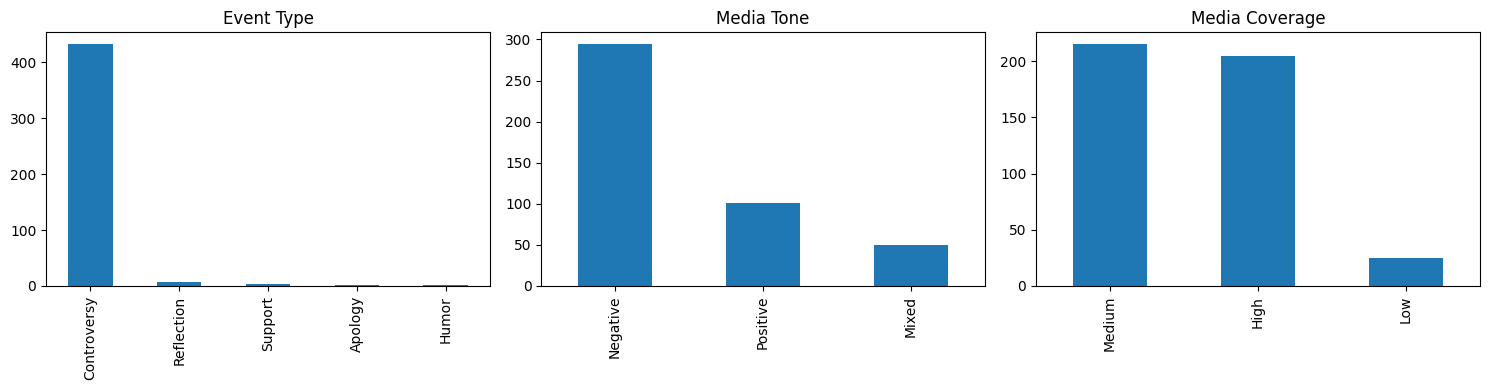

In [199]:
import pandas as pd
import matplotlib.pyplot as plt

event_type = {"Controversy": 432, "Reflection": 7, "Support": 3, "Apology": 2, "Humor": 1}
tone = {"Negative": 294, "Positive": 101, "Mixed": 50}
coverage = {"Medium": 215, "High": 205, "Low": 25}

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

pd.Series(event_type).plot(kind="bar", ax=axes[0], title="Event Type")
pd.Series(tone).plot(kind="bar", ax=axes[1], title="Media Tone")
pd.Series(coverage).plot(kind="bar", ax=axes[2], title="Media Coverage")

plt.tight_layout()
plt.show()

In [200]:
nfl_cleaned['Event Type'].value_counts()

Event Type
Controversy    39
Support        16
Humor          10
Reflection      7
Apology         3
Name: count, dtype: int64

In [201]:
nfl_cleaned['Media Tone'].value_counts()

Media Tone
Negative     33
Positive     25
Mixed        16
Positive      1
Name: count, dtype: int64

In [202]:
nfl_cleaned['Media Coverage'].value_counts()

Media Coverage
Medium    44
Low       21
High      10
Name: count, dtype: int64

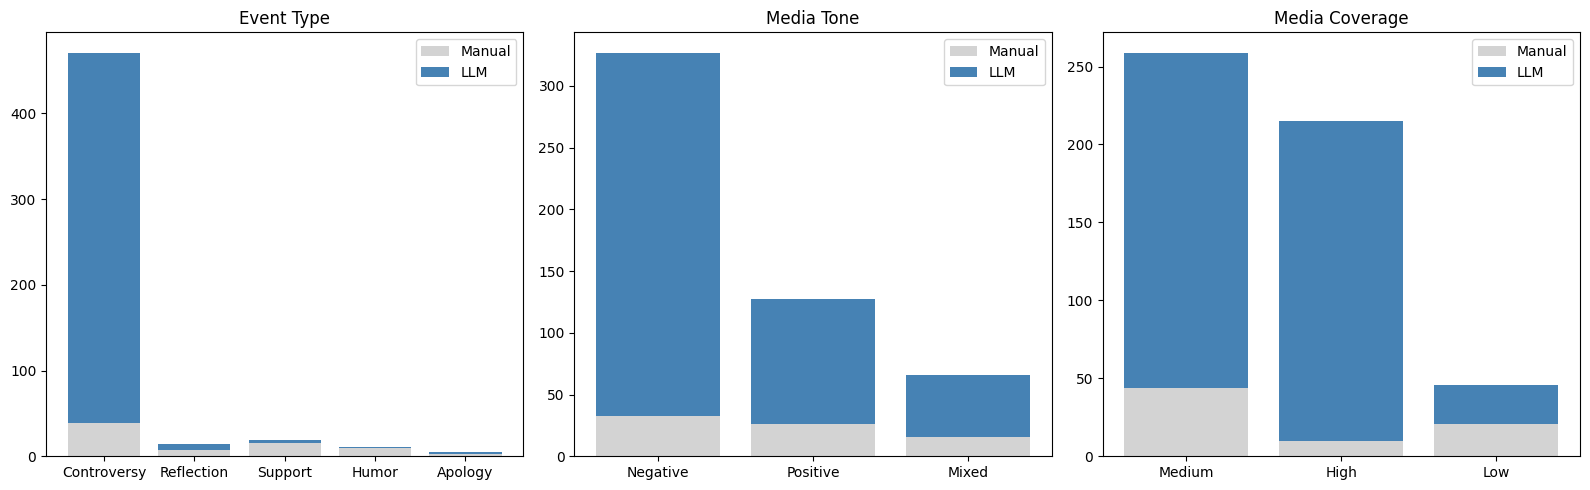

In [204]:
import pandas as pd
import matplotlib.pyplot as plt

# split into aligned categories
event_categories = ["Controversy", "Reflection", "Support", "Humor","Apology"]

llm_event = [432, 7, 3, 1, 2]
manual_event = [39, 7, 16, 10, 3]

tone_categories = ["Negative", "Positive", "Mixed"]
llm_tone = [294, 101, 50]
manual_tone = [33, 26, 16]

coverage_categories = ["Medium", "High", "Low"]
llm_coverage = [215, 205, 25]
manual_coverage = [44, 10, 21]


fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# ---------------- EVENT TYPE ----------------
axes[0].bar(event_categories, manual_event, label="Manual", color="lightgray")
axes[0].bar(event_categories, llm_event, bottom=manual_event, label="LLM", color="steelblue")
axes[0].set_title("Event Type")
axes[0].legend()

# ---------------- MEDIA TONE ----------------
axes[1].bar(tone_categories, manual_tone, label="Manual", color="lightgray")
axes[1].bar(tone_categories, llm_tone, bottom=manual_tone, label="LLM", color="steelblue")
axes[1].set_title("Media Tone")
axes[1].legend()

# ---------------- MEDIA COVERAGE ----------------
axes[2].bar(coverage_categories, manual_coverage, label="Manual", color="lightgray")
axes[2].bar(coverage_categories, llm_coverage, bottom=manual_coverage, label="LLM", color="steelblue")
axes[2].set_title("Media Coverage")
axes[2].legend()

plt.tight_layout()
plt.show()

In [166]:
nfl_cleaned.columns

Index(['ID', 'Player Name', 'Player Status', 'Year of Event', 'Statement Made',
       'Event Description', 'Platform', 'Event Type', 'Media Tone',
       'Post Status', 'Media Coverage', 'Sources', 'URL'],
      dtype='str')

In [167]:
test_df = pd.concat([nfl_cleaned, filtered_news_cleaned], join='outer', ignore_index=False)

In [168]:
test_df.head()

,ID,Player Name,Player Status,Year of Event,Statement Made,Event Description,Platform,Event Type,Media Tone,Post Status,Media Coverage,Sources,URL,index,title,max_similarity,most_similar_anchor_idx,most_similar_anchor_title
0,1.0,Jason Kelce,Retired,2025.0,Man I love the 4th...we all share in common th...,Instagram post celebrating July 4th sparked ba...,Instagram,Controversy,Negative,Active,High,"Fox News, US Weekly, Yahoo Sports",https://www.yahoo.com/entertainment/articles/j...,NaN,NaN,NaN,NaN,NaN
1,2.0,Warren Sapp,Retired,2025.0,Texas is Fake Football,Response to a tweet that praises Texas running...,Twitter/X,Controversy,Negative,Deleted,Medium,"MSN, Yahoo Sports",https://sports.yahoo.com/articles/nfl-legend-w...,NaN,NaN,NaN,NaN,NaN
2,3.0,Puka Nacua,Playing,2025.0,I deeply apologize...I do not stand for any fo...,Apologizes after making antisemitic gesture du...,Instagram,Apology,Negative,Deleted,High,"CNN, Yahoo Sports, BBC",https://www.cnn.com/2025/12/18/sport/football-...,NaN,NaN,NaN,NaN,NaN
3,4.0,Travis Kelce,Playing,2024.0,happy easter...#shoutout to Jesus for takin on...,Wishing everyone a Happy Easter while making j...,Twitter/X,Controversy,Mixed,Active,High,"Yahoo Sports, E! News, People",https://www.yahoo.com/entertainment/articles/t...,NaN,NaN,NaN,NaN,NaN
4,5.0,Deion Sanders,Playing,2024.0,He will be a top 5 pick. Where yo son going?,Response to a fan about the draft pick ranking...,Twitter/X,Controversy,Negative,Deleted,Medium,"Yahoo Sports, ESPN, Fox News",https://sports.yahoo.com/article/deion-sanders...,NaN,NaN,NaN,NaN,NaN


In [169]:
test_df = test_df.drop(columns=['ID', 'index'])

In [170]:
test_df.shape

(520, 16)

In [171]:
type(test_df['Year of Event'])

pandas.Series

In [172]:
test_df['Year of Event'] = test_df['Year of Event'].astype(int)

In [173]:
test_df.head()

,Player Name,Player Status,Year of Event,Statement Made,Event Description,Platform,Event Type,Media Tone,Post Status,Media Coverage,Sources,URL,title,max_similarity,most_similar_anchor_idx,most_similar_anchor_title
0,Jason Kelce,Retired,2025,Man I love the 4th...we all share in common th...,Instagram post celebrating July 4th sparked ba...,Instagram,Controversy,Negative,Active,High,"Fox News, US Weekly, Yahoo Sports",https://www.yahoo.com/entertainment/articles/j...,NaN,NaN,NaN,NaN
1,Warren Sapp,Retired,2025,Texas is Fake Football,Response to a tweet that praises Texas running...,Twitter/X,Controversy,Negative,Deleted,Medium,"MSN, Yahoo Sports",https://sports.yahoo.com/articles/nfl-legend-w...,NaN,NaN,NaN,NaN
2,Puka Nacua,Playing,2025,I deeply apologize...I do not stand for any fo...,Apologizes after making antisemitic gesture du...,Instagram,Apology,Negative,Deleted,High,"CNN, Yahoo Sports, BBC",https://www.cnn.com/2025/12/18/sport/football-...,NaN,NaN,NaN,NaN
3,Travis Kelce,Playing,2024,happy easter...#shoutout to Jesus for takin on...,Wishing everyone a Happy Easter while making j...,Twitter/X,Controversy,Mixed,Active,High,"Yahoo Sports, E! News, People",https://www.yahoo.com/entertainment/articles/t...,NaN,NaN,NaN,NaN
4,Deion Sanders,Playing,2024,He will be a top 5 pick. Where yo son going?,Response to a fan about the draft pick ranking...,Twitter/X,Controversy,Negative,Deleted,Medium,"Yahoo Sports, ESPN, Fox News",https://sports.yahoo.com/article/deion-sanders...,NaN,NaN,NaN,NaN


In [174]:
final_data = test_df.copy()

In [176]:
final_data.to_csv("final_dataset.csv", index=False)

In [178]:
final_data.info()

<class 'pandas.DataFrame'>
Index: 520 entries, 0 to 444
Data columns (total 16 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Player Name                323 non-null    str    
 1   Player Status              116 non-null    str    
 2   Year of Event              520 non-null    int64  
 3   Statement Made             75 non-null     str    
 4   Event Description          75 non-null     str    
 5   Platform                   75 non-null     str    
 6   Event Type                 520 non-null    str    
 7   Media Tone                 520 non-null    str    
 8   Post Status                75 non-null     str    
 9   Media Coverage             520 non-null    str    
 10  Sources                    520 non-null    str    
 11  URL                        520 non-null    str    
 12  title                      445 non-null    str    
 13  max_similarity             445 non-null    float64
 14  most_simil

In [179]:
final_data.shape

(520, 16)

In [177]:
final_data.describe()

,Year of Event,max_similarity,most_similar_anchor_idx
count,520.000000,445.000000,445.000000
mean,2023.015385,0.263365,38.808989
std,2.251044,0.134181,20.109652
min,2019.000000,0.140074,0.000000
25%,2021.000000,0.168548,25.000000
50%,2023.000000,0.206166,44.000000
75%,2025.000000,0.310522,53.000000
max,2026.000000,0.713237,70.000000


In [191]:
final_data["Event Type"].value_counts()

Event Type
Controversy    471
Support         19
Reflection      14
Humor           11
Apology          5
Name: count, dtype: int64

In [192]:
final_data["Media Tone"].value_counts()

Media Tone
Negative     327
Positive     126
Mixed         63
Neutral        3
Positive       1
Name: count, dtype: int64

In [193]:
final_data["Media Coverage"].value_counts()

Media Coverage
Medium    259
High      215
Low        46
Name: count, dtype: int64

-------------------